In [7]:
import logging
import random
import pandas as pd
import random
import matplotlib.pylab as plt
import numpy as np
from pathlib import Path
import sys



logger = logging.getLogger(name=__name__)

### my own notebooks

repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.append(str(repo_root))

import src.vertexModel2 as vertexModel2
import src.inputMechanicalParametersModel2 as MechanicalParams2
import src.auxFunctions as auxFunctions



### Modelling apoptosis by contracting a single edge

In [8]:
def collapse_single_edge(cellmap, geom, energyContributions_model, edge_id):
    """
    Collapses a single specified edge by merging its two vertices into one.
    The new vertex is placed at the midpoint of the original edge.
    
    Parameters:
    -----------
    cellmap : object
        The cellmap containing vertex and edge DataFrames
    geom : object
        Geometry handler
    energyContributions_model : object
        Energy model for the system
    edge_id : int
        ID of the edge to collapse (must be an inside edge, not boundary)
    
    Returns:
    --------
    cellmap : object
        Updated cellmap after edge collapse
    """
    
    logger.info(f"Collapsing edge: {edge_id}")
    
    # Verifying edge exists
    if edge_id not in cellmap.edge_df.index:
        raise ValueError(f"Edge {edge_id} not found in cellmap.edge_df")
    
    # Finding the two vertices belonging to the edge
    edge_row = cellmap.edge_df.loc[edge_id]
    v1 = edge_row['srce']
    v2 = edge_row['trgt']
    
    logger.info(f"Merging vertices {v1} and {v2}")
    
    # Verifying both vertices exist
    if v1 not in cellmap.vert_df.index or v2 not in cellmap.vert_df.index:
        raise ValueError(f"Vertex {v1} or {v2} not found in cellmap.vert_df")
    
    # Calculating midpoint coordinates along the chosen edge 
    x1 = cellmap.vert_df.loc[v1, 'x']
    y1 = cellmap.vert_df.loc[v1, 'y']
    x2 = cellmap.vert_df.loc[v2, 'x']
    y2 = cellmap.vert_df.loc[v2, 'y']
    
    midpoint_x = (x1 + x2) / 2
    midpoint_y = (y1 + y2) / 2
    
    # Creating a new vertex at the midpoint
    new_vertex_id = max(cellmap.vert_df.index) + 1 if not cellmap.vert_df.empty else 0
    new_vertex_data = cellmap.vert_df.loc[v1].copy()
    new_vertex_data['x'] = midpoint_x
    new_vertex_data['y'] = midpoint_y
    cellmap.vert_df.loc[new_vertex_id] = new_vertex_data
    
    # Rewiring edges by vertex proximity
    cellmap.edge_df.loc[cellmap.edge_df["srce"] == v1, "srce"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["srce"] == v2, "srce"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["trgt"] == v1, "trgt"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["trgt"] == v2, "trgt"] = new_vertex_id
    
    # Deleting the collapsed edge and its parallel edge
    parallel_edges = cellmap.edge_df[
        ((cellmap.edge_df["srce"] == v1) & (cellmap.edge_df["trgt"] == v2)) |
        ((cellmap.edge_df["srce"] == v2) & (cellmap.edge_df["trgt"] == v1))
    ].index.tolist()
    
    edges_to_delete = [edge_id] + parallel_edges
    cellmap.edge_df.drop(edges_to_delete, inplace=True, errors='ignore')
    
    # Deleting old vertices
    cellmap.vert_df.drop([v1, v2], inplace=True, errors='ignore')
    
    # Removing self-loops (safety mechanism, shouldn't exist)
    cellmap.edge_df = cellmap.edge_df[cellmap.edge_df["srce"] != cellmap.edge_df["trgt"]]
    
    # Removing duplicate edges (if many consecutive collapses form any)
    cellmap.edge_df = cellmap.edge_df.drop_duplicates(subset=['srce', 'trgt'])
    
    # Resetting indices and updating geometry
    cellmap.reset_index()
    
    # Updating active vertices
    if hasattr(cellmap, 'active_verts'):
        cellmap.active_verts = list(cellmap.vert_df.index)
    
    geom.update_all(cellmap)
    
    # Recomputing energy and relaxing the model post edge contraction
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, endTime=40
    )
    
    return cellmap

### Example of a single edge contraction

In [14]:
# Initializing cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

# Changing outside vertices mechanics
high_viscosity_value = 200000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
# Relaxing model 
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 20)


Topology changed!


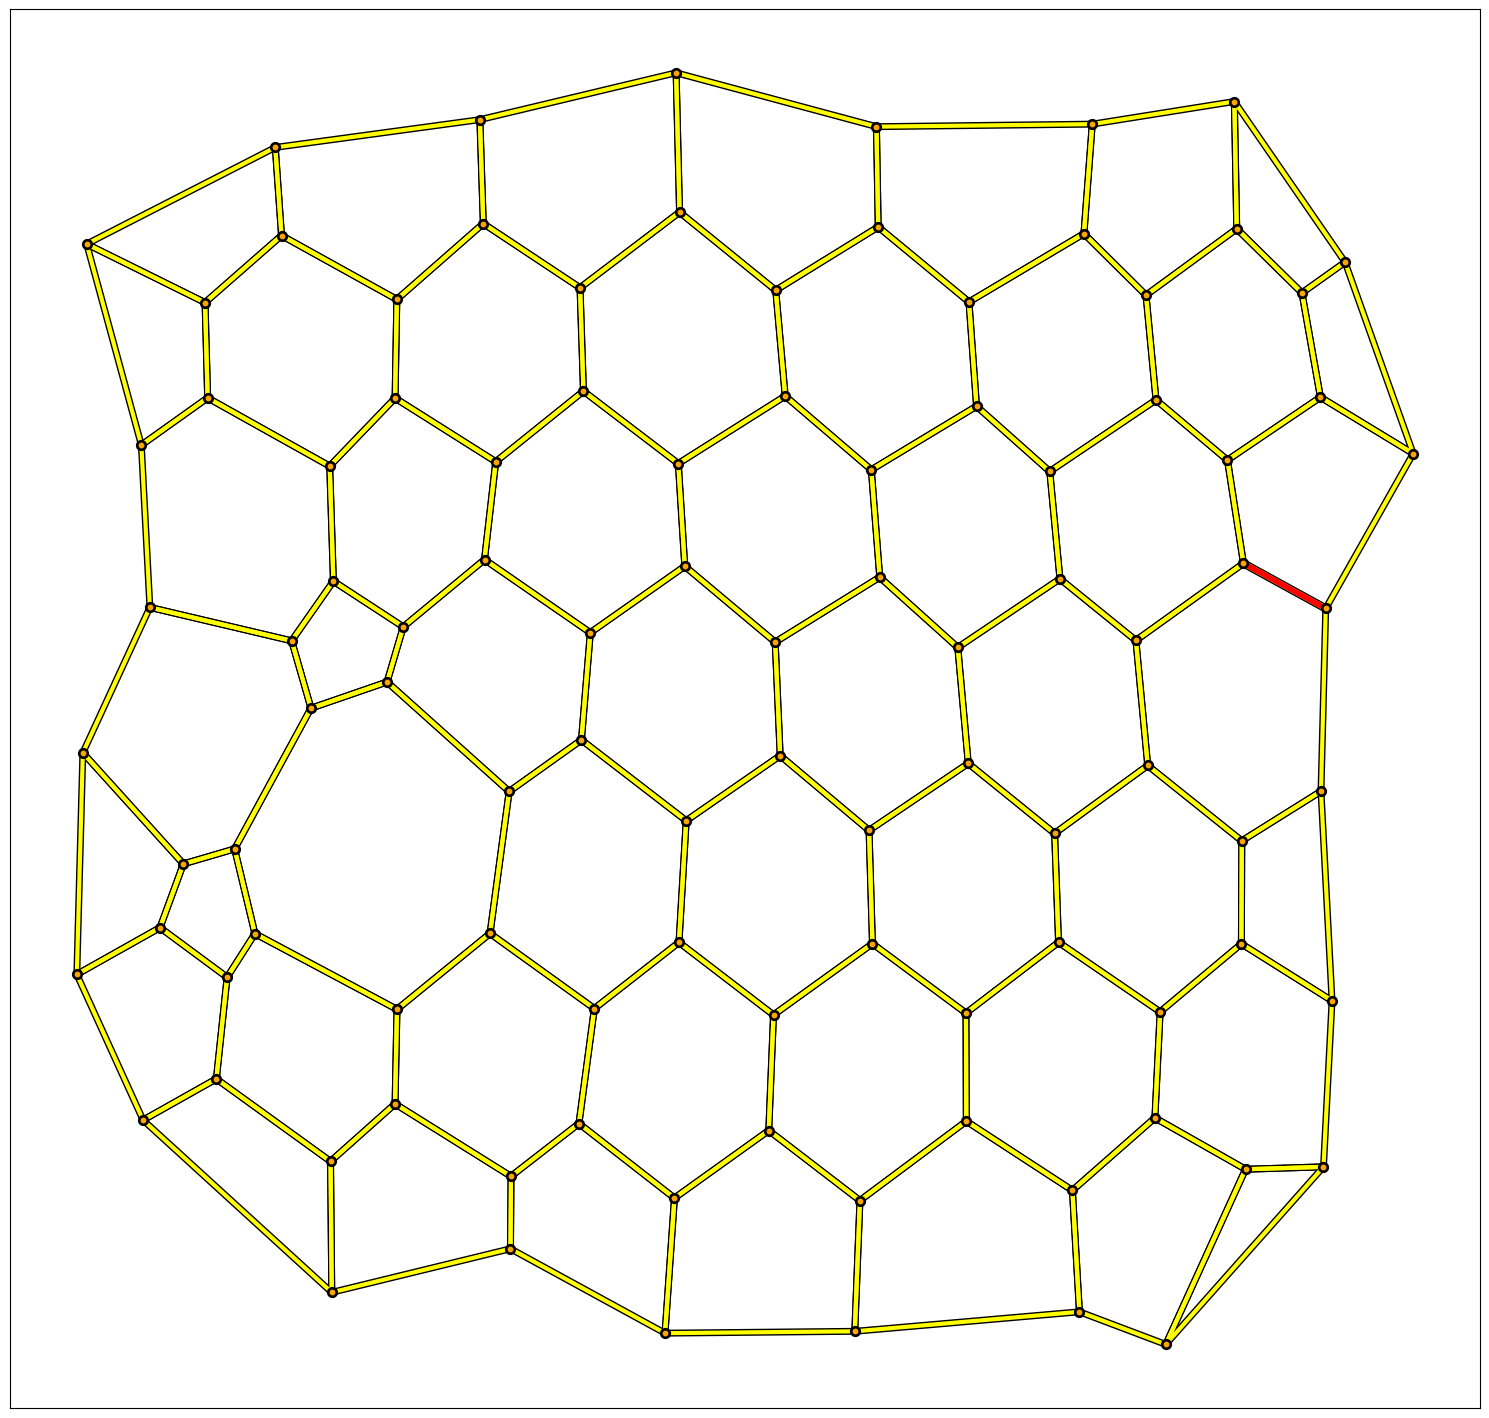

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [15]:
auxFunctions.highlight_edge_on_cellmap(cellmap_init, edge_id=10, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

In [16]:
cellmap = collapse_single_edge(cellmap_init, geom, energyContributions_model, 10)

Topology changed!


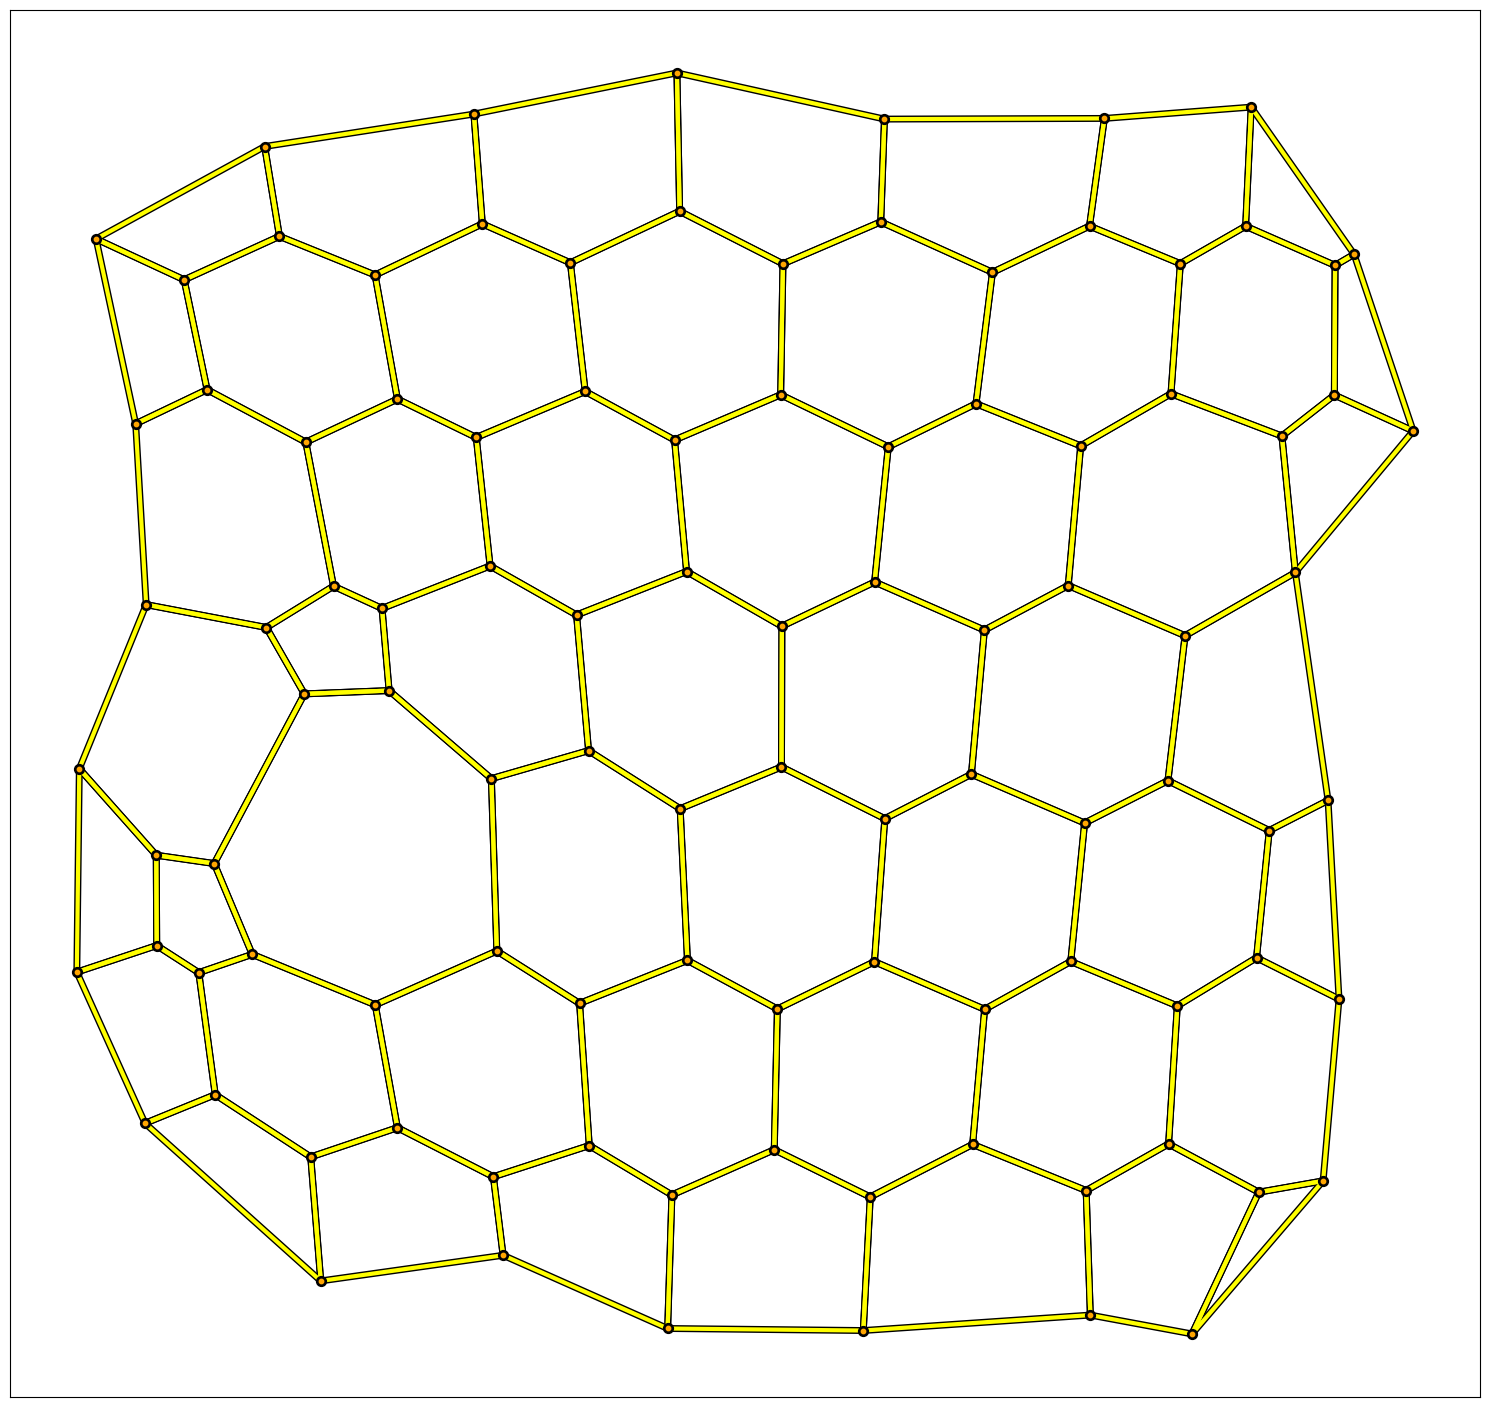

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [18]:
auxFunctions.highlight_edge_on_cellmap(cellmap_init, edge_id=None, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

### Contract 2 adjacent edges

In [19]:
def collapse_two_adjacent_edges(cellmap, geom, energyContributions_model, first_edge_id=None):
    """
    Collapses two adjacent edges that share a vertex.
    
    Process:
    1. Pick (or use specified) first edge
    2. Randomly choose one of its two vertices as the pivot
    3. Collapse the first edge → new vertex at midpoint
    4. Find an edge connected to the new vertex
    5. Collapse that edge as the second collapse
    """
    
    # Selecting first edge to collapse
    if first_edge_id is None:
        if cellmap.edge_df.empty:
            raise ValueError("No edges available to collapse")
        first_edge_id = random.choice(cellmap.edge_df.index)
    
    if first_edge_id not in cellmap.edge_df.index:
        raise ValueError(f"Edge {first_edge_id} not found in cellmap.edge_df")
    
    # Collapsing the first edge
    result = collapse_single_edge(cellmap, geom, energyContributions_model, first_edge_id)
    cellmap = result[0] if isinstance(result, tuple) else result
    
    # Finding the newly created vertex
    new_vertex = cellmap.vert_df.index.max()
    
    # Finding and collapsing another edge connected to the new vertex
    edges_from_new = cellmap.edge_df[
        (cellmap.edge_df["srce"] == new_vertex) | (cellmap.edge_df["trgt"] == new_vertex)
    ].index.tolist()
    
    if edges_from_new:
        second_edge_id = random.choice(edges_from_new)
        result = collapse_single_edge(cellmap, geom, energyContributions_model, second_edge_id)
        cellmap = result[0] if isinstance(result, tuple) else result
    
    return cellmap

### Example of contraction of two edges

In [20]:
## Initializing cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

# Changing outside vertices mechanics to create a 'capsule-like' boundary
high_viscosity_value = 200000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
# Relaxing the model
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 20)


Topology changed!


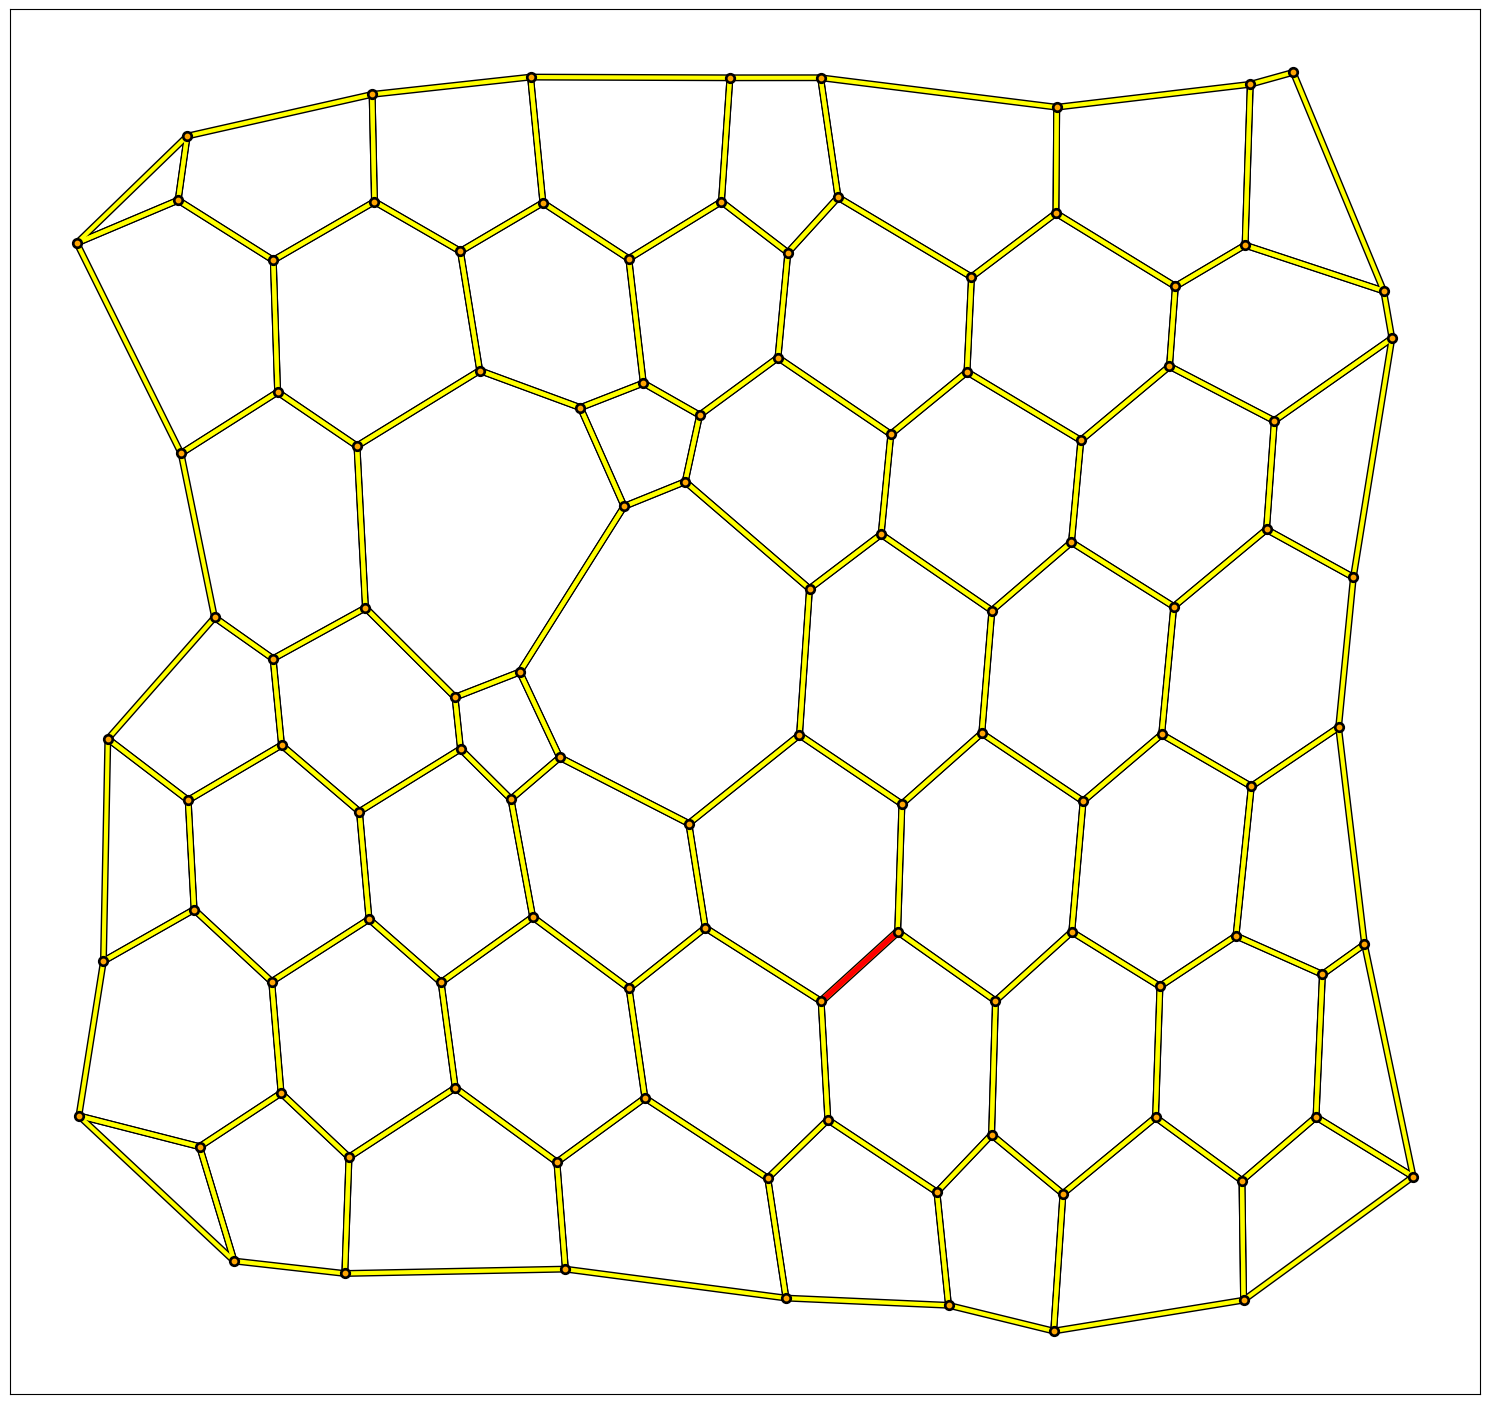

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [21]:
auxFunctions.highlight_edge_on_cellmap(cellmap_init, edge_id=50, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

In [22]:
cellmap = collapse_two_adjacent_edges(cellmap_init, geom, energyContributions_model, first_edge_id=50)

Topology changed!
Topology changed!


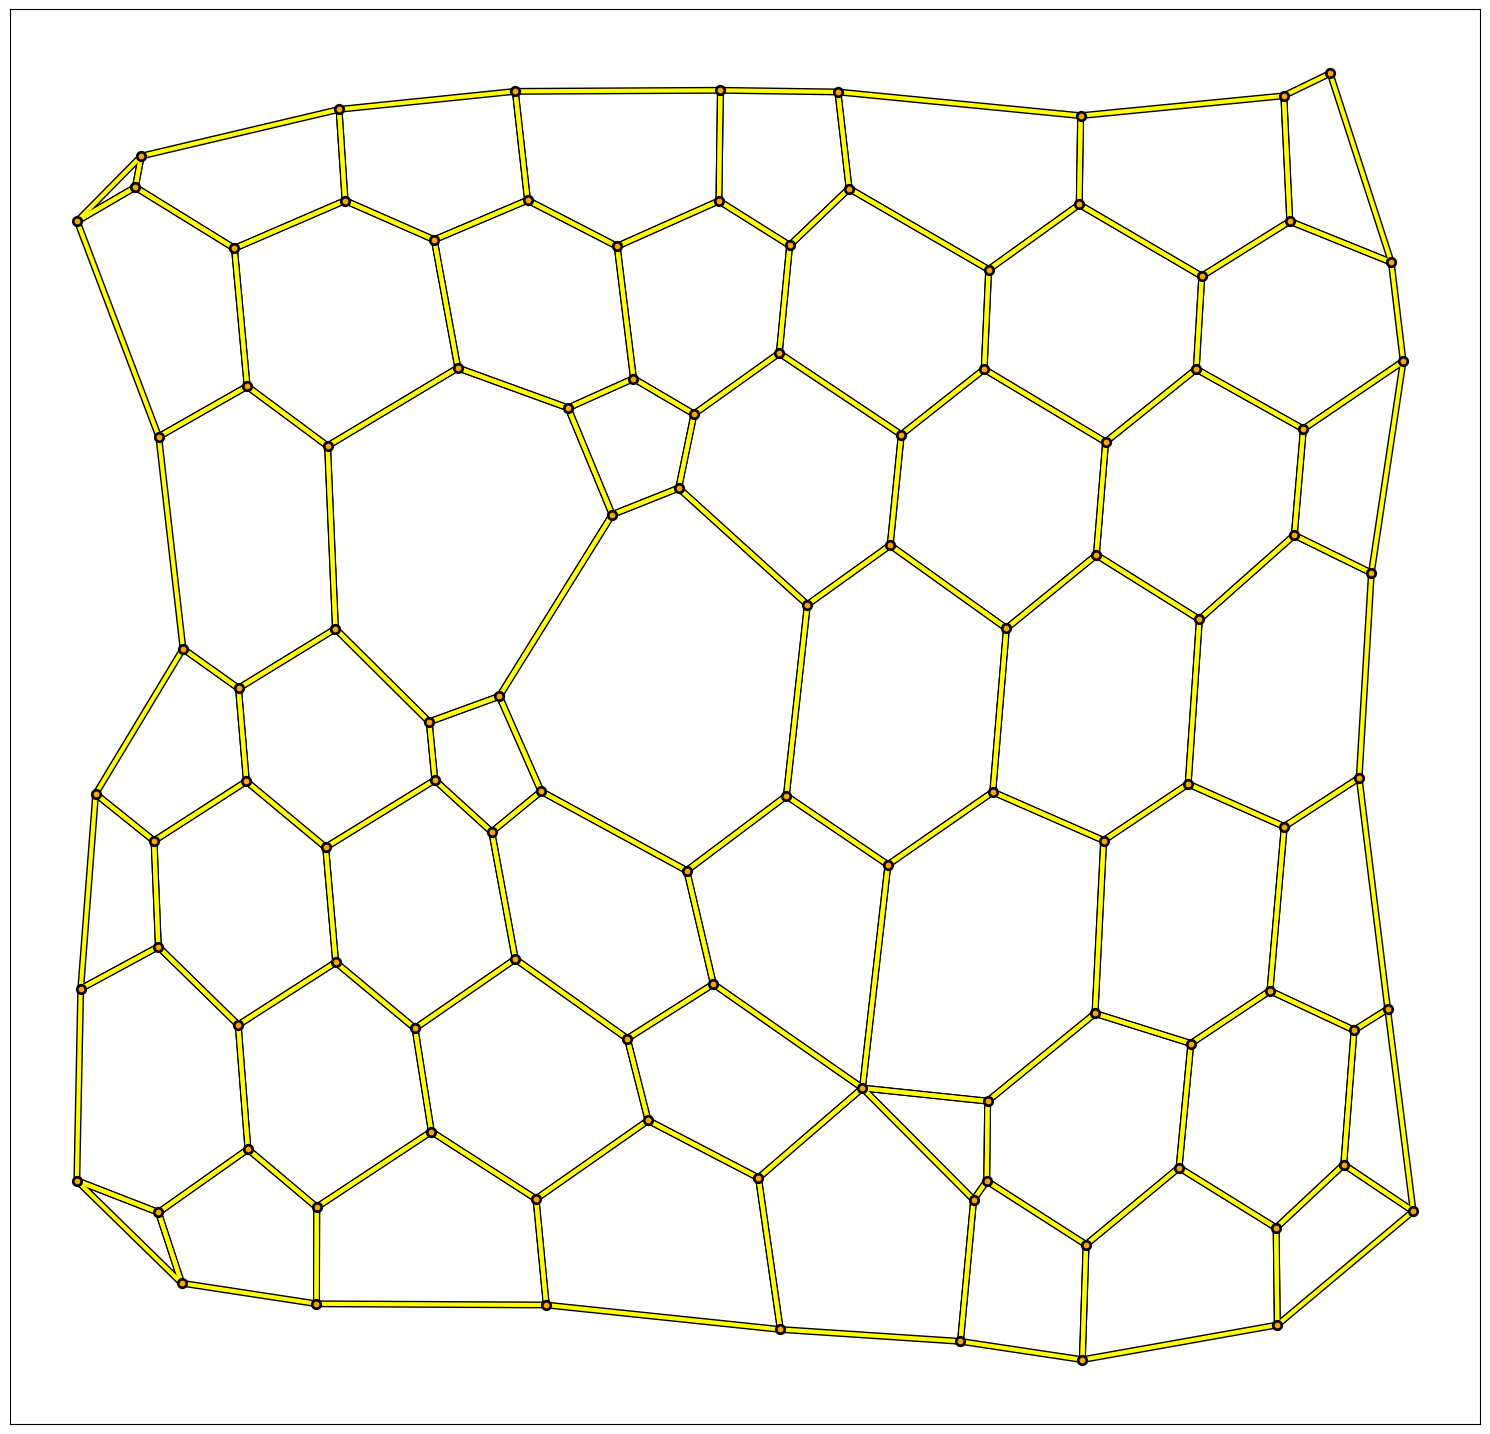

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [23]:
auxFunctions.highlight_edge_on_cellmap(cellmap, edge_id=None, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

### Contract all edges around a vertex

In [24]:
def collapse_all_edges_around_vertex(cellmap, geom, energyContributions_model, vertex_id):
    """
    Collapses all edges around a specified interior vertex.
    The original vertex is kept; all surrounding vertices are deleted
    and their edges rewired to the original vertex.
    """
    
    logger.info(f"Collapsing around vertex: {vertex_id}")

    # Verifing chosen vertex exists
    if vertex_id not in cellmap.vert_df.index:
        raise ValueError(f"Vertex {vertex_id} not found in cellmap.vert_df")

    # Finding all vertices directly connected to the chosen vertex
    edges_from_chosen = cellmap.edge_df[
        (cellmap.edge_df["srce"] == vertex_id) | (cellmap.edge_df["trgt"] == vertex_id)
    ]
    
    surrounding_vertices = set()
    for _, edge in edges_from_chosen.iterrows():
        if edge['srce'] == vertex_id:
            surrounding_vertices.add(edge['trgt'])
        else:
            surrounding_vertices.add(edge['srce'])
    
    surrounding_vertices = list(surrounding_vertices)

    logger.info(f"Removing surrounding vertices: {surrounding_vertices}")
    logger.info(f"Keeping original vertex: {vertex_id}")

    # Dropping all edges connected to the chosen vertex
    edges_to_drop = cellmap.edge_df[
        (cellmap.edge_df["srce"] == vertex_id) | (cellmap.edge_df["trgt"] == vertex_id)
    ].index
    cellmap.edge_df.drop(edges_to_drop, inplace=True)

    # Rewiring edges of surrounding vertices to the chosen vertex
    for old_vertex in surrounding_vertices:
        cellmap.edge_df.loc[cellmap.edge_df["srce"] == old_vertex, "srce"] = vertex_id
        cellmap.edge_df.loc[cellmap.edge_df["trgt"] == old_vertex, "trgt"] = vertex_id

    # Removing surrounding vertices (keeping the chosen vertex
    cellmap.vert_df.drop(surrounding_vertices, inplace=True, errors='ignore')

    # Removing invalid edges, self-loops, duplicates
    existing_verts = set(cellmap.vert_df.index)
    cellmap.edge_df = cellmap.edge_df[
        (cellmap.edge_df["srce"].isin(existing_verts)) & 
        (cellmap.edge_df["trgt"].isin(existing_verts))
    ]
    cellmap.edge_df = cellmap.edge_df[cellmap.edge_df["srce"] != cellmap.edge_df["trgt"]]
    cellmap.edge_df = cellmap.edge_df.drop_duplicates(subset=['srce', 'trgt'])

    # Resetting indices and updating geometry
    cellmap.reset_index()
    
    if hasattr(cellmap, 'active_verts'):
        cellmap.active_verts = list(cellmap.vert_df.index)
    
    geom.update_all(cellmap)

    # Recomputing energy and relaxing the model
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, endTime=40
    )

    return cellmap

### Example of contraction of all edges around a vertex

In [25]:
# Initializing cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

#Changing outside vertices mechanics
high_viscosity_value = 200000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
# Relaxing the model
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 200)


Topology changed!


(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

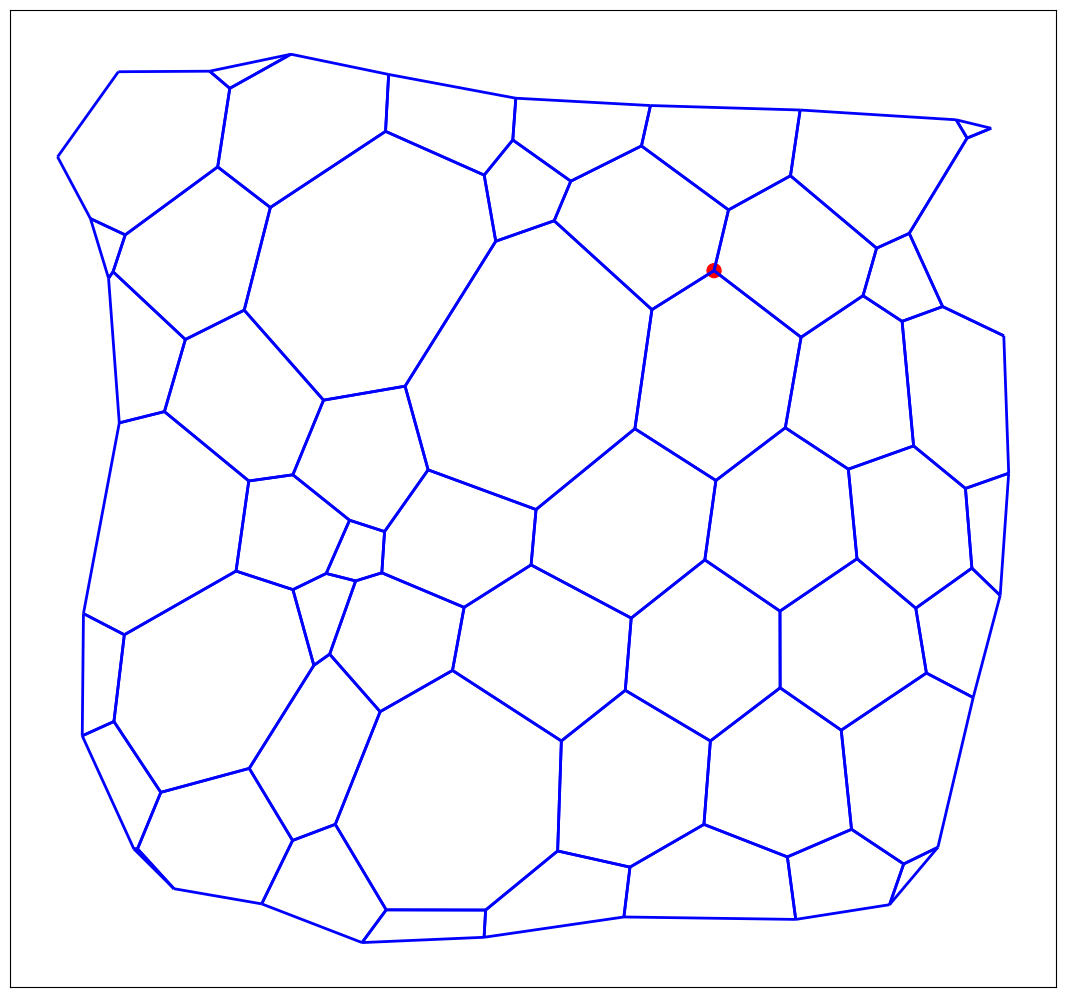

In [26]:
auxFunctions.highlight_vertices(cellmap_init, geom, [50], default_color='white', highlight_color='red', default_size=10, highlight_size=100)


In [27]:
cellmap = collapse_all_edges_around_vertex(cellmap_init, geom, energyContributions_model, 50)


Topology changed!


(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

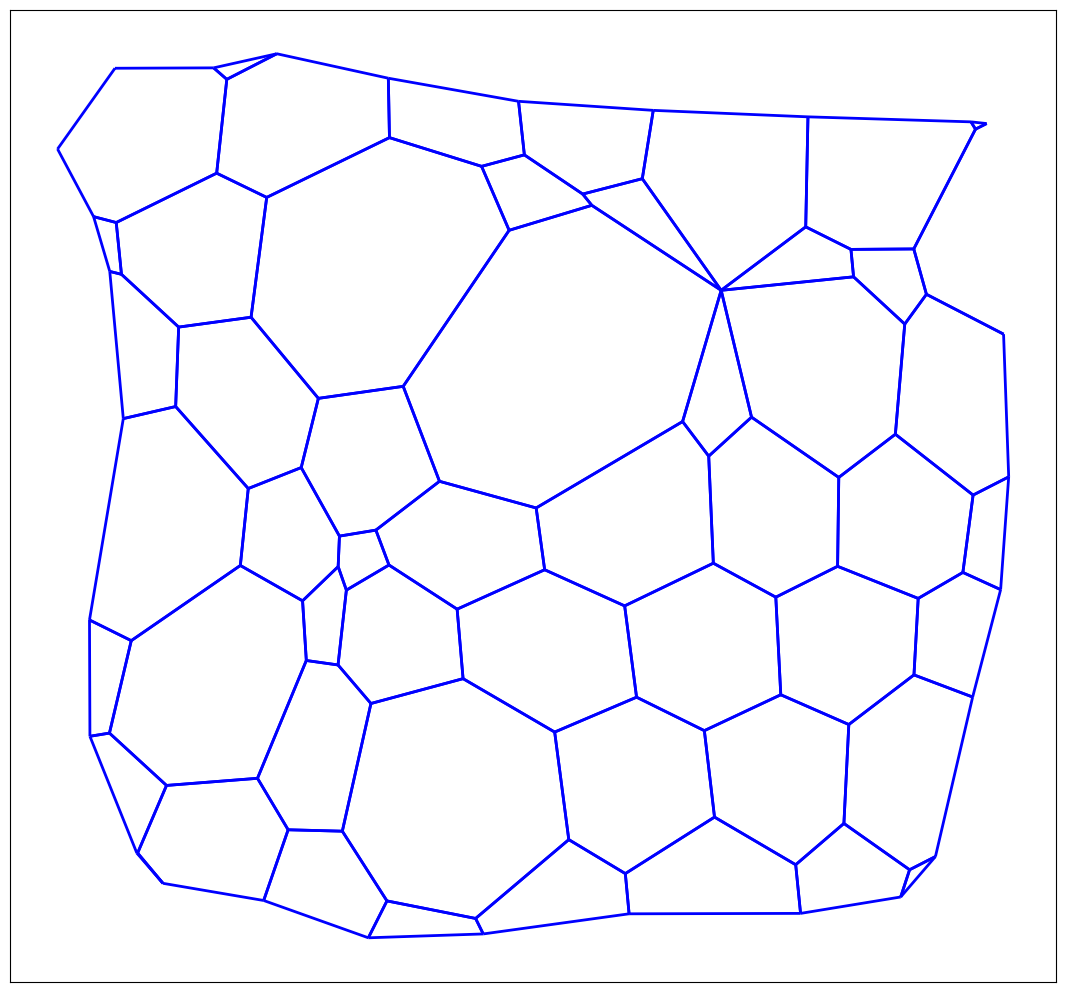

In [29]:
auxFunctions.highlight_vertices(cellmap_init, geom, [None], default_color='white', highlight_color='red', default_size=50, highlight_size=100)


### FRC division!

### Division by inseritng a vertex in the middle of a chosen edge

In [58]:
def division_by_vertex_insertion(cellmap, geom, energyContributions_model, edge_id, endTime=50):
    """Split an edge by inserting a vertex at its midpoint."""
    
    # Get source and target of original edge
    srce, trgt = cellmap.edge_df.loc[edge_id, ["srce", "trgt"]]
    
    # Get coordinates
    x1 = cellmap.vert_df.loc[srce, 'x']
    y1 = cellmap.vert_df.loc[srce, 'y']
    x2 = cellmap.vert_df.loc[trgt, 'x']
    y2 = cellmap.vert_df.loc[trgt, 'y']
    
    # Calculate midpoint
    new_x = (x1 + x2) / 2
    new_y = (y1 + y2) / 2
    
    # Get FULL original edge data (copy ALL columns)
    original_edge_data = cellmap.edge_df.loc[edge_id].copy()
    original_face = original_edge_data["face"]
    
    # Find opposite edge and its FULL data
    opposites = cellmap.edge_df[
        (cellmap.edge_df["srce"] == trgt) & (cellmap.edge_df["trgt"] == srce)
    ]
    
    if not opposites.empty:
        opp_id = opposites.index[0]
        opposite_edge_data = cellmap.edge_df.loc[opp_id].copy()
        opposite_face = opposite_edge_data["face"]
    else:
        opp_id = None
        opposite_edge_data = None
        opposite_face = None
    
    # Create new vertex at midpoint, COPYING properties from srce vertex
    new_vert = len(cellmap.vert_df)
    # Copy ALL vertex properties from srce (including is_active, viscosity, etc.)
    new_vertex_data = cellmap.vert_df.loc[srce].copy()
    new_vertex_data['x'] = new_x
    new_vertex_data['y'] = new_y
    cellmap.vert_df.loc[new_vert] = new_vertex_data
    
    # Delete original and opposite edges
    cellmap.edge_df.drop(edge_id, inplace=True)
    if opp_id is not None:
        cellmap.edge_df.drop(opp_id, inplace=True)
    
    # Add 4 new edges, COPYING ALL columns from original/opposite edges
    new_edges_list = []
    
    # Edge 1: A → M (copy ALL from original edge)
    new_edge1 = original_edge_data.copy()
    new_edge1["srce"] = srce
    new_edge1["trgt"] = new_vert
    new_edge1["face"] = original_face
    new_edges_list.append(new_edge1)
    
    # Edge 2: M → A (copy ALL from opposite edge, or original if no opposite)
    if opposite_edge_data is not None:
        new_edge2 = opposite_edge_data.copy()
    else:
        new_edge2 = original_edge_data.copy()
    new_edge2["srce"] = new_vert
    new_edge2["trgt"] = srce
    new_edge2["face"] = opposite_face
    new_edges_list.append(new_edge2)
    
    # Edge 3: M → B (copy ALL from original edge)
    new_edge3 = original_edge_data.copy()
    new_edge3["srce"] = new_vert
    new_edge3["trgt"] = trgt
    new_edge3["face"] = original_face
    new_edges_list.append(new_edge3)
    
    # Edge 4: B → M (copy ALL from opposite edge, or original if no opposite)
    if opposite_edge_data is not None:
        new_edge4 = opposite_edge_data.copy()
    else:
        new_edge4 = original_edge_data.copy()
    new_edge4["srce"] = trgt
    new_edge4["trgt"] = new_vert
    new_edge4["face"] = opposite_face
    new_edges_list.append(new_edge4)
    
    # Convert to DataFrame and concatenate
    new_edges_df = pd.DataFrame(new_edges_list)
    cellmap.edge_df = pd.concat([cellmap.edge_df, new_edges_df], ignore_index=True)
    
    # Get IDs of new edges (last 4 rows)
    new_edges = list(range(len(cellmap.edge_df) - 4, len(cellmap.edge_df)))
    
    # Update geometry
    geom.update_all(cellmap)
    cellmap.reset_index()
    
    # Plotting before model relaxation
    auxFunctions.highlight_vertices(cellmap, geom, [new_vert], 
                                    default_color='white', highlight_color='red', 
                                    default_size=50, highlight_size=100)
    plt.title(f"Vertex {new_vert} BEFORE relaxation (random position)")
    plt.show()

    # Relaxing the system
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, endTime=endTime
    )
    
    # Plotting after relaxation
    auxFunctions.highlight_vertices(cellmap, geom, [new_vert], 
                                    default_color='white', highlight_color='red', 
                                    default_size=50, highlight_size=100)
    plt.title(f"Vertex {new_vert} AFTER relaxation (midpoint)")
    plt.show()
    
    return cellmap, new_vert, new_edges

### Example of symmetric edge division by vertex insertion

In [59]:
# Initialize cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

#Change outside vertices mechanics
high_viscosity_value = 200000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
#energyContributions_model.compute_energy(cellmap)
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 200)


Topology changed!


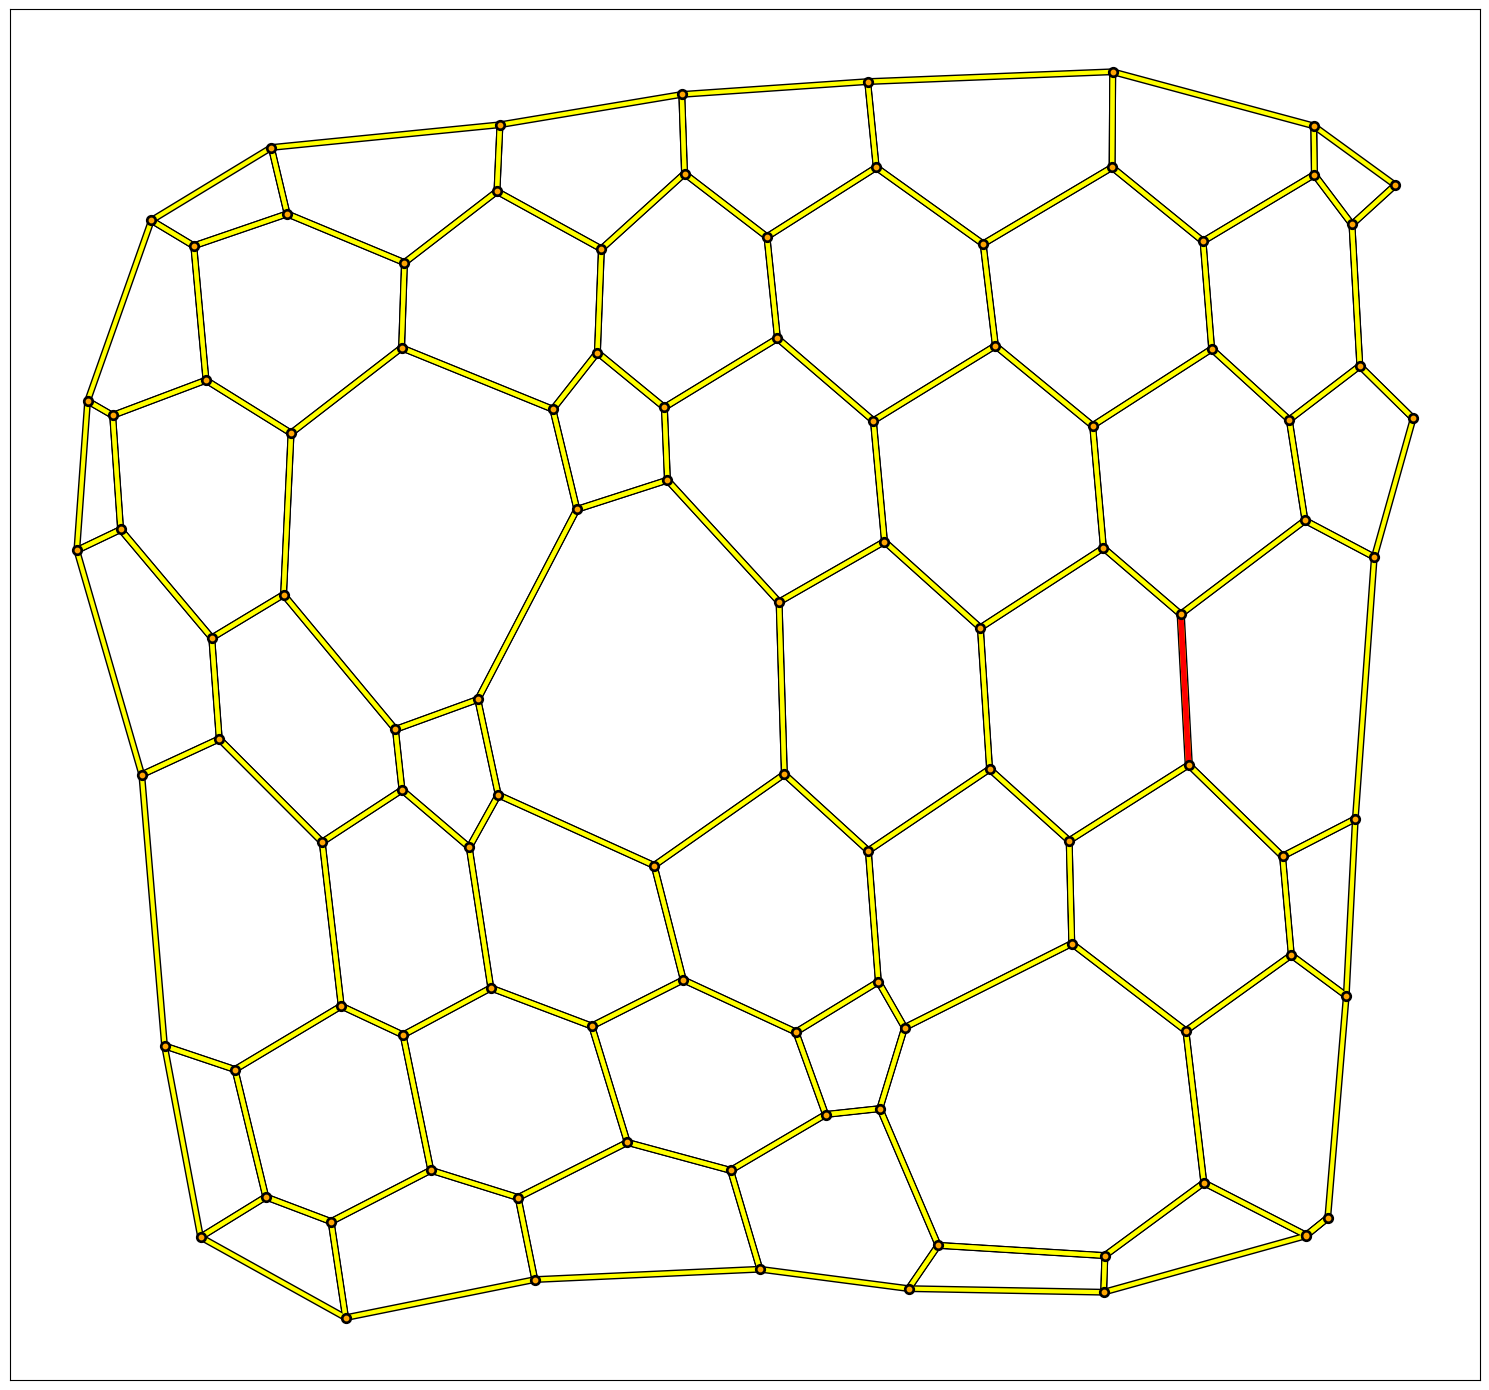

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [65]:
auxFunctions.highlight_edge_on_cellmap(cellmap_init, edge_id=240, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

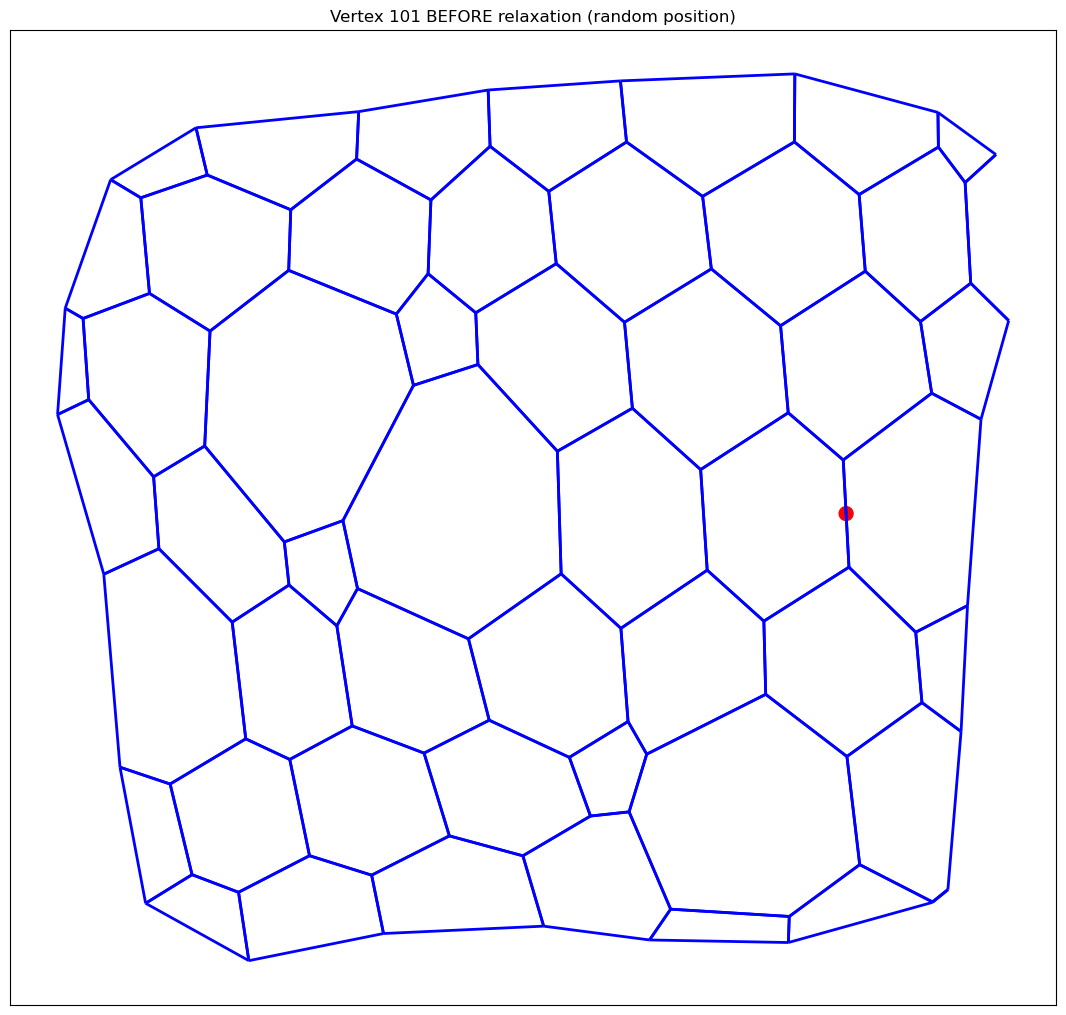

Topology changed!


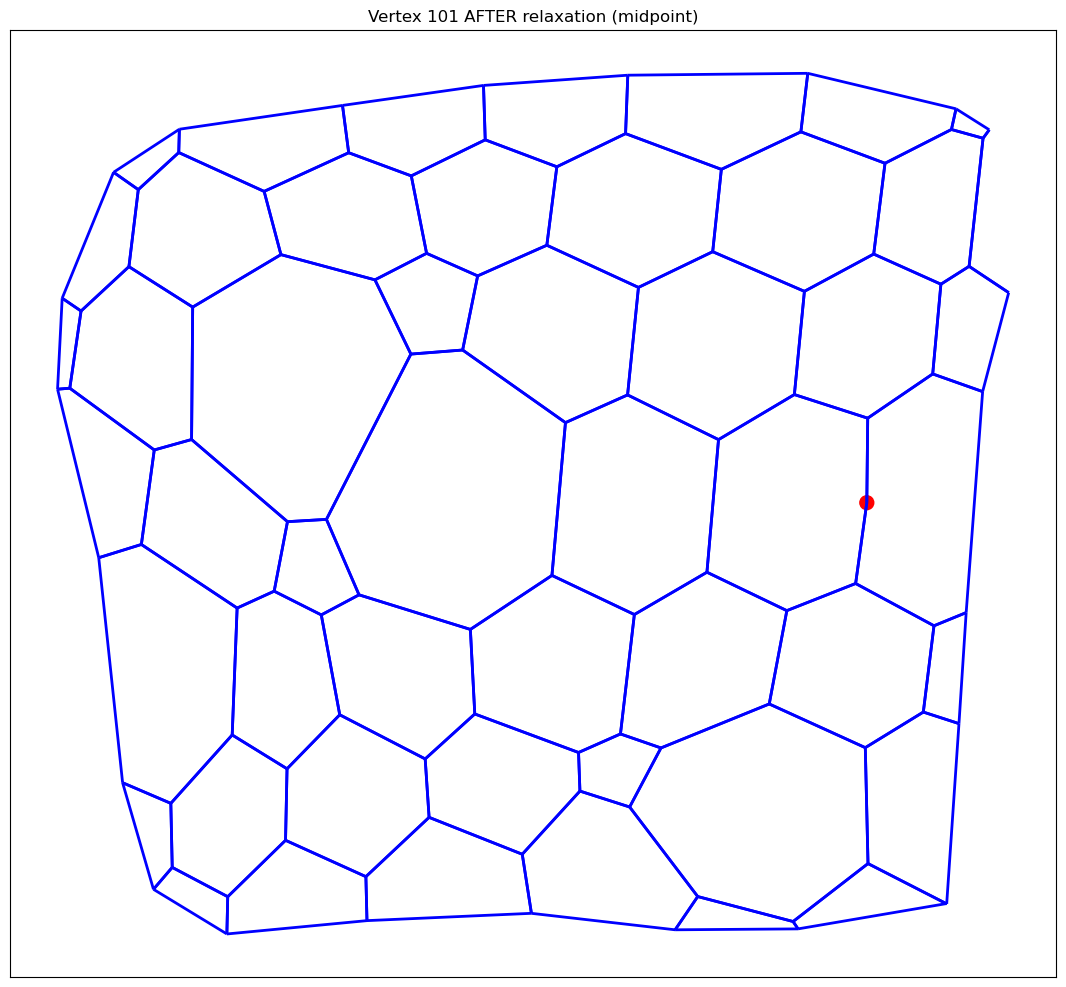

In [66]:
cellmap, new_vert, new_edges = division_by_vertex_insertion(cellmap_init, geom, energyContributions_model, 240, endTime=100)



### Code to test division was carried out correctly

In [43]:
def debug_full_face_edges(cellmap, new_vert):
    """Show ALL edges of faces that contain the new vertex."""
    
    print("\n" + "="*50)
    print(f"NEW VERTEX: {new_vert}")
    print("="*50)
    
    # Find edges connected to new vertex
    edges_from_new = cellmap.edge_df[
        (cellmap.edge_df["srce"] == new_vert) | (cellmap.edge_df["trgt"] == new_vert)
    ]
    
    # Get unique faces from these edges
    faces = edges_from_new["face"].dropna().unique()
    
    print(f"\nFaces containing vertex {new_vert}: {sorted(faces)}")
    
    for face in sorted(faces):
        print("\n" + "-"*40)
        print(f"FACE {face} — ALL EDGES:")
        print("-"*40)
        
        # Get ALL edges belonging to this face
        all_face_edges = cellmap.edge_df[cellmap.edge_df["face"] == face]
        
        print(f"Total edges in face {face}: {len(all_face_edges)}")
        print("\nEdge list (in order around face):")
        
        for idx, row in all_face_edges.iterrows():
            marker = "← NEW VERTEX" if (row['srce'] == new_vert or row['trgt'] == new_vert) else ""
            print(f"  Edge {idx}: {row['srce']} → {row['trgt']}{marker}")
        
        # Show vertices in order around the face
        print(f"\nVertices in face {face} (in order):")
        vertices = []
        current_edge = all_face_edges.iloc[0]
        current_vert = current_edge['srce']
        
        for _ in range(len(all_face_edges)):
            vertices.append(current_vert)
            next_edge = all_face_edges[
                (all_face_edges['srce'] == current_vert)
            ]
            if not next_edge.empty:
                current_vert = next_edge.iloc[0]['trgt']
        
        vertices.append(vertices[0])  # Close the loop
        print(f"  {' → '.join(str(v) for v in vertices)}")
    
    print("\n" + "="*50)

In [44]:
debug_full_face_edges(cellmap, new_vert)


NEW VERTEX: 98

Faces containing vertex 98: [14, 22]

----------------------------------------
FACE 14 — ALL EDGES:
----------------------------------------
Total edges in face 14: 7

Edge list (in order around face):
  Edge 18: 20.0 → 21.0
  Edge 25: 19.0 → 8.0
  Edge 26: 8.0 → 9.0
  Edge 28: 9.0 → 10.0
  Edge 30: 21.0 → 19.0
  Edge 265: 10.0 → 98.0← NEW VERTEX
  Edge 267: 98.0 → 20.0← NEW VERTEX

Vertices in face 14 (in order):
  20.0 → 21.0 → 19.0 → 8.0 → 9.0 → 10.0 → 98.0 → 20.0

----------------------------------------
FACE 22 — ALL EDGES:
----------------------------------------
Total edges in face 22: 7

Edge list (in order around face):
  Edge 21: 22.0 → 20.0
  Edge 34: 12.0 → 22.0
  Edge 79: 10.0 → 50.0
  Edge 86: 51.0 → 12.0
  Edge 87: 50.0 → 51.0
  Edge 266: 98.0 → 10.0← NEW VERTEX
  Edge 268: 20.0 → 98.0← NEW VERTEX

Vertices in face 22 (in order):
  22.0 → 20.0 → 98.0 → 10.0 → 50.0 → 51.0 → 12.0 → 22.0



In [45]:
def check_face_orientation(cellmap, face_id):
    """
    Check if all edges in a face form a consistent directed loop.
    
    Returns:
    - consistent: True if edges form a continuous loop
    - orientation: 'clockwise' or 'counterclockwise' (if consistent)
    """
    
    # Get all edges belonging to this face
    face_edges = cellmap.edge_df[cellmap.edge_df["face"] == face_id].copy()
    
    if len(face_edges) == 0:
        print(f"Face {face_id}: No edges found")
        return False, None
    
    print(f"\n{'='*50}")
    print(f"FACE {face_id} — DIRECTION CHECK")
    print(f"{'='*50}")
    
    # Build the edge sequence
    edges_list = face_edges.index.tolist()
    
    # Start with first edge
    current_srce = face_edges.iloc[0]['srce']
    current_trgt = face_edges.iloc[0]['trgt']
    
    sequence = [(edges_list[0], current_srce, current_trgt)]
    
    # Track used edges
    used_edges = {edges_list[0]}
    current_vert = current_trgt
    
    # Follow the loop
    consistent = True
    for _ in range(len(face_edges) - 1):
        # Find next edge where srce == current_vert
        next_edge = face_edges[face_edges['srce'] == current_vert]
        
        if next_edge.empty:
            print(f"BREAK: No edge starting at {current_vert}")
            consistent = False
            break
        
        if len(next_edge) > 1:
            print(f"WARNING: Multiple edges starting at {current_vert}: {next_edge.index.tolist()}")
        
        next_id = next_edge.index[0]
        next_srce = next_edge.iloc[0]['srce']
        next_trgt = next_edge.iloc[0]['trgt']
        
        if next_id in used_edges:
            print(f"BREAK: Edge {next_id} already used (cycle detected early)")
            consistent = False
            break
        
        sequence.append((next_id, next_srce, next_trgt))
        used_edges.add(next_id)
        current_vert = next_trgt
    
    # Check if we returned to start
    if consistent and current_vert != sequence[0][1]:
        print(f"BREAK: Loop not closed — ended at {current_vert}, started at {sequence[0][1]}")
        consistent = False
    
    # Print the sequence
    print(f"\nEdge sequence:")
    for i, (eid, s, t) in enumerate(sequence):
        arrow = "→" if i < len(sequence)-1 else "→ (back to start)"
        print(f"  Edge {eid}: {s} {arrow} {t}")
    
    if consistent:
        print(f"\n FACE {face_id} is CONSISTENT — forms a closed loop")
        
        # Determine orientation (clockwise or counterclockwise)
        # Calculate signed area (shoelace formula)
        vertices = []
        for _, s, t in sequence:
            vertices.append(s)
        vertices.append(sequence[0][1])  # Add closing vertex
        
        # Get coordinates
        coords = []
        for v in vertices:
            x = cellmap.vert_df.loc[v, 'x']
            y = cellmap.vert_df.loc[v, 'y']
            coords.append((x, y))
        
        # Shoelace formula
        area = 0
        for i in range(len(coords) - 1):
            area += coords[i][0] * coords[i+1][1] - coords[i+1][0] * coords[i][1]
        area /= 2
        
        orientation = "counterclockwise" if area > 0 else "clockwise"
        print(f"  Orientation: {orientation} (area = {area:.4f})")
        
        return True, orientation
    
    else:
        print(f"\nFACE {face_id} is INCONSISTENT")
        return False, None


def check_both_faces(cellmap, new_vert):
    """Check orientation for both faces containing new vertex."""
    
    print("\n" + "="*60)
    print("CHECKING FACE ORIENTATIONS FOR NEW VERTEX", new_vert)
    print("="*60)
    
    # Find faces containing new_vert
    edges = cellmap.edge_df[
        (cellmap.edge_df["srce"] == new_vert) | (cellmap.edge_df["trgt"] == new_vert)
    ]
    faces = edges["face"].dropna().unique()
    
    results = {}
    for face_id in sorted(faces):
        consistent, orientation = check_face_orientation(cellmap, face_id)
        results[face_id] = (consistent, orientation)
    
    print("\n" + "="*60)
    print("SUMMARY:")
    print("="*60)
    for face_id, (consistent, orientation) in results.items():
        status = "correct" if consistent else "wrong"
        print(f"  {status} Face {face_id}: {orientation if consistent else 'INCONSISTENT'}")
    
    return results

In [46]:
check_both_faces(cellmap, new_vert)



CHECKING FACE ORIENTATIONS FOR NEW VERTEX 98

FACE 14 — DIRECTION CHECK

Edge sequence:
  Edge 18: 20.0 → 21.0
  Edge 30: 21.0 → 19.0
  Edge 25: 19.0 → 8.0
  Edge 26: 8.0 → 9.0
  Edge 28: 9.0 → 10.0
  Edge 265: 10.0 → 98.0
  Edge 267: 98.0 → (back to start) 20.0

 FACE 14 is CONSISTENT — forms a closed loop
  Orientation: counterclockwise (area = 0.8216)

FACE 22 — DIRECTION CHECK

Edge sequence:
  Edge 21: 22.0 → 20.0
  Edge 268: 20.0 → 98.0
  Edge 266: 98.0 → 10.0
  Edge 79: 10.0 → 50.0
  Edge 87: 50.0 → 51.0
  Edge 86: 51.0 → 12.0
  Edge 34: 12.0 → (back to start) 22.0

 FACE 22 is CONSISTENT — forms a closed loop
  Orientation: counterclockwise (area = 0.8511)

SUMMARY:
  correct Face 14: counterclockwise
  correct Face 22: counterclockwise


{14: (True, 'counterclockwise'), 22: (True, 'counterclockwise')}

### Division with new vertex insertion not in the middle of edge

In [ ]:
def division_by_vertex_insertion_random_location(cellmap, geom, energyContributions_model, edge_id, endTime=40):
    """Split an edge by inserting a vertex at a RANDOM location along the edge."""
    
    # Getting source and target of chosen edge
    srce, trgt = cellmap.edge_df.loc[edge_id, ["srce", "trgt"]]
    
    x1 = cellmap.vert_df.loc[srce, 'x']
    y1 = cellmap.vert_df.loc[srce, 'y']
    x2 = cellmap.vert_df.loc[trgt, 'x']
    y2 = cellmap.vert_df.loc[trgt, 'y']
    
    # Calculating a random fraction along the edge (0 to 1)
    fraction = random.uniform(0, 1)
    
    # Calculating new vertex coordinates at the random location
    new_x = x1 + fraction * (x2 - x1)
    new_y = y1 + fraction * (y2 - y1)
    
    # Getting original edge data (all columns)
    original_edge_data = cellmap.edge_df.loc[edge_id].copy()
    original_face = original_edge_data["face"]
    
    # Finding opposite edge and its data
    opposites = cellmap.edge_df[
        (cellmap.edge_df["srce"] == trgt) & (cellmap.edge_df["trgt"] == srce)
    ]
    
    if not opposites.empty:
        opp_id = opposites.index[0]
        opposite_edge_data = cellmap.edge_df.loc[opp_id].copy()
        opposite_face = opposite_edge_data["face"]
    else:
        opp_id = None
        opposite_edge_data = None
        opposite_face = None
    
    # Creating new vertex at the random location, copying properties from srce vertex
    new_vert = len(cellmap.vert_df)
    new_vertex_data = cellmap.vert_df.loc[srce].copy()
    new_vertex_data['x'] = new_x
    new_vertex_data['y'] = new_y
    cellmap.vert_df.loc[new_vert] = new_vertex_data
    
    # Deleting original and opposite edges
    cellmap.edge_df.drop(edge_id, inplace=True)
    if opp_id is not None:
        cellmap.edge_df.drop(opp_id, inplace=True)
    
    # Adding 4 new edges, copying all columns from original/opposite edges
    new_edges_list = []
    
    # Edge 1: A → M (copy ALL from original edge)
    new_edge1 = original_edge_data.copy()
    new_edge1["srce"] = srce
    new_edge1["trgt"] = new_vert
    new_edge1["face"] = original_face
    new_edges_list.append(new_edge1)
    
    # Edge 2: M → A (copy ALL from opposite edge, or original if no opposite)
    if opposite_edge_data is not None:
        new_edge2 = opposite_edge_data.copy()
    else:
        new_edge2 = original_edge_data.copy()
    new_edge2["srce"] = new_vert
    new_edge2["trgt"] = srce
    new_edge2["face"] = opposite_face
    new_edges_list.append(new_edge2)
    
    # Edge 3: M → B (copy ALL from original edge)
    new_edge3 = original_edge_data.copy()
    new_edge3["srce"] = new_vert
    new_edge3["trgt"] = trgt
    new_edge3["face"] = original_face
    new_edges_list.append(new_edge3)
    
    # Edge 4: B → M (copy ALL from opposite edge, or original if no opposite)
    if opposite_edge_data is not None:
        new_edge4 = opposite_edge_data.copy()
    else:
        new_edge4 = original_edge_data.copy()
    new_edge4["srce"] = trgt
    new_edge4["trgt"] = new_vert
    new_edge4["face"] = opposite_face
    new_edges_list.append(new_edge4)
    
    # Convert to DataFrame and concatenate
    new_edges_df = pd.DataFrame(new_edges_list)
    cellmap.edge_df = pd.concat([cellmap.edge_df, new_edges_df], ignore_index=True)
    
    # Getting IDs of new edges (last 4 rows)
    new_edges = list(range(len(cellmap.edge_df) - 4, len(cellmap.edge_df)))
    
    # Updating geometry
    geom.update_all(cellmap)
    cellmap.reset_index()
    
    # Plotting before model relaxation
    auxFunctions.highlight_vertices(cellmap, geom, [new_vert], 
                                    default_color='white', highlight_color='red', 
                                    default_size=50, highlight_size=100)
    plt.title(f"Vertex {new_vert} BEFORE relaxation (random position)")
    plt.show()
    
    # Relaxing the model
    energyContributions_model.compute_energy(cellmap)
    [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, endTime=endTime
    )
    
    # Plotting after model relaxation
    auxFunctions.highlight_vertices(cellmap, geom, [new_vert], 
                                    default_color='white', highlight_color='red', 
                                    default_size=50, highlight_size=100)
    plt.title(f"Vertex {new_vert} AFTER relaxation")
    plt.show()
    
    return cellmap, new_vert, new_edges

### Example of assymetrical edge division by vertex insertion

In [48]:
# Initializing cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

#Change outside vertices mechanics
high_viscosity_value = 200000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
#energyContributions_model.compute_energy(cellmap)
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 200)


Topology changed!


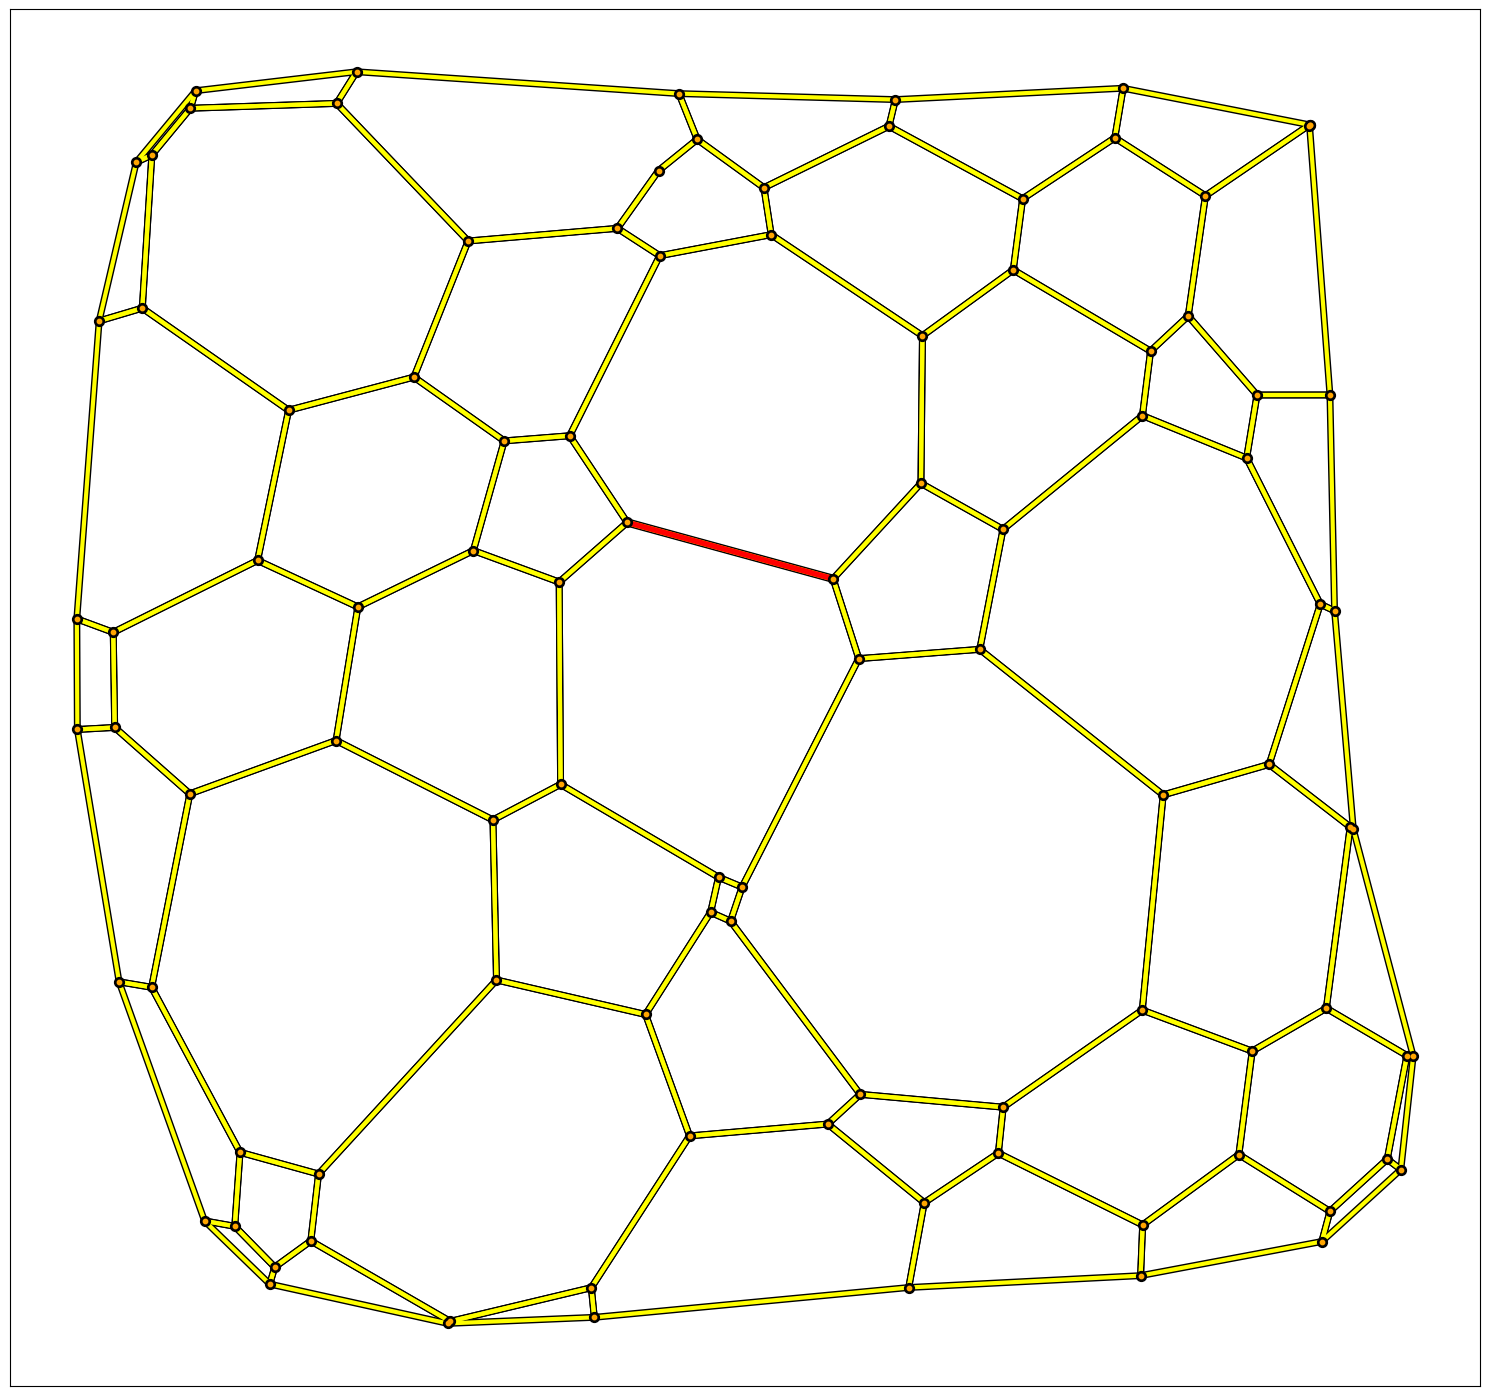

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [56]:
auxFunctions.highlight_edge_on_cellmap(cellmap_init, edge_id=70, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

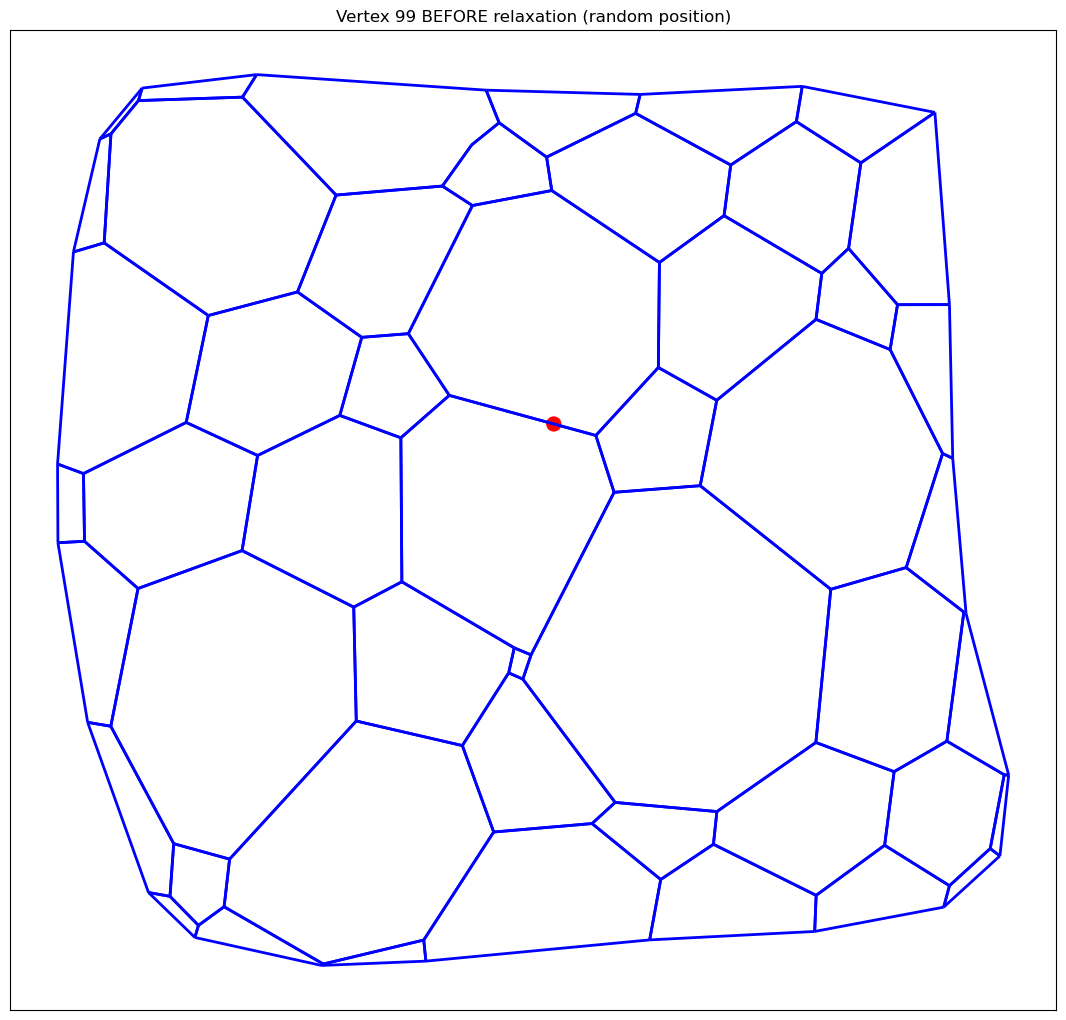

Topology changed!


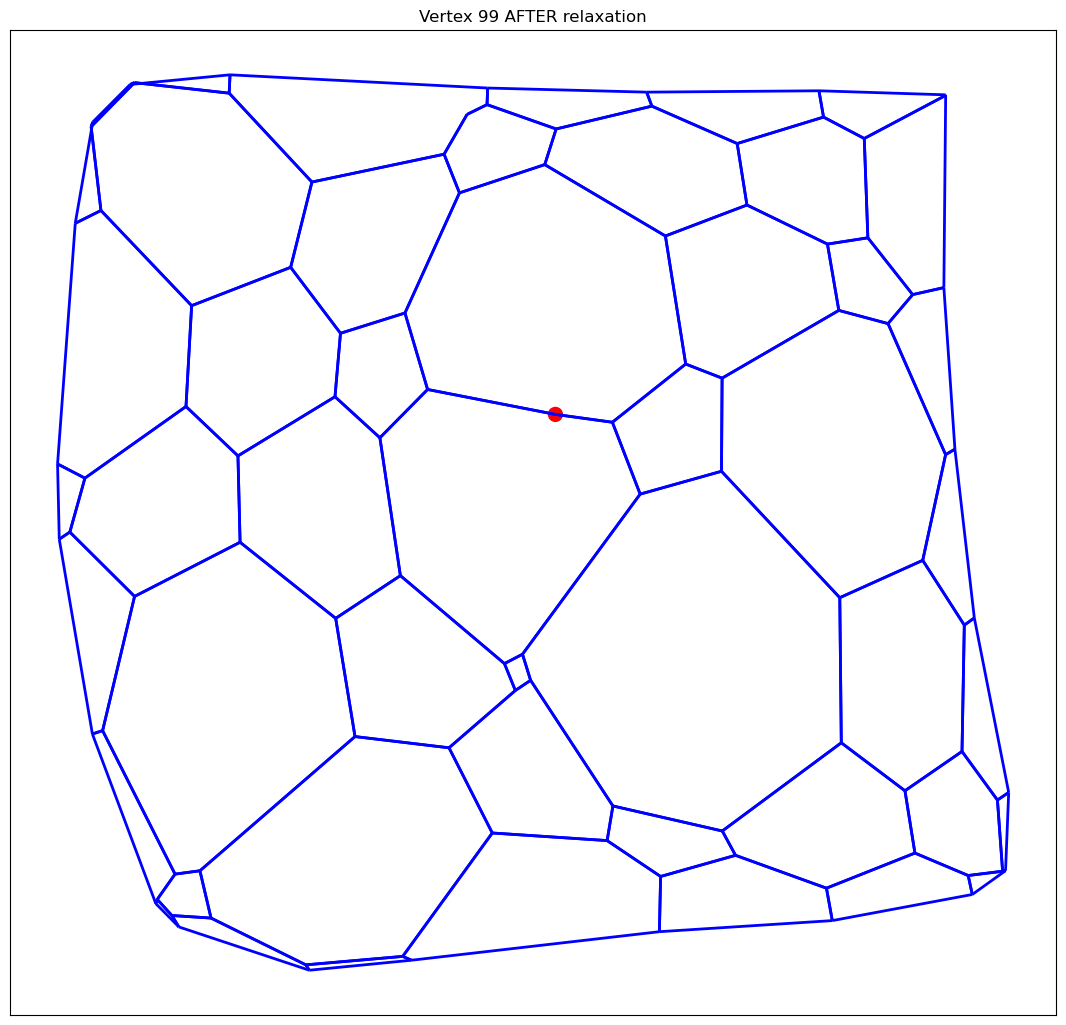

In [57]:

cellmap, new_vert, new_edges = division_by_vertex_insertion_random_location(cellmap_init, geom, energyContributions_model, 70, endTime=100)




### Division by splitting a vertex

In [67]:
def split_vertex(cellmap, chosen_vertex, geom, energyContributions_model, distance, retry_attempts=3):
    """
    Safely divide a vertex by creating a nearby new vertex and rewiring edges.
    On failure, rollback and retry up to `retry_attempts` times.

    Returns:
        (cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index)
        or (cellmap, chosen_vertex, None, None, None) if all attempts fail.
    """

    original_vert_df = cellmap.vert_df.copy()
    original_edge_df = cellmap.edge_df.copy()

    new_vert_index = None
    new_edge_index = None
    opposite_edge_index = None

    attempt = 0
    while attempt < retry_attempts:
        try:
            # Creating temorary cellmap copies to allow rollback
            temp_vert_df = cellmap.vert_df.copy()
            temp_edge_df = cellmap.edge_df.copy()

            # Finding connected edges to the chosen vertex
            connected_edges = temp_edge_df[
                (temp_edge_df['srce'] == chosen_vertex) |
                (temp_edge_df['trgt'] == chosen_vertex)
            ].copy()

            # Creating new vertex inside a specified radius from chosen vertex
            new_vert_data = temp_vert_df.loc[chosen_vertex].copy()
            angle = np.random.uniform(0, 2*np.pi)
            dx = distance * np.cos(angle)
            dy = distance * np.sin(angle)
            new_vert_data[cellmap.coords] = temp_vert_df.loc[chosen_vertex, cellmap.coords] + [dx, dy]

            new_vert_index = int(temp_vert_df.index.max()) + 1
            temp_vert_df.loc[new_vert_index] = new_vert_data
    
        
            # Creating a new pair of edges
            # Template: first connected edge (copies its all mechanical properties)

            source_edge = connected_edges.iloc[0]

            template = source_edge.copy()

            new_edge_index = int(temp_edge_df.index.max()) + 1
            opposite_edge_index = new_edge_index + 1

            new_edge = template.copy()
            new_edge["srce"], new_edge["trgt"] = chosen_vertex, new_vert_index
            new_edge["face"] = np.nan

            opposite_edge = template.copy()
            opposite_edge["srce"], opposite_edge["trgt"] = new_vert_index, chosen_vertex
            opposite_edge["face"] = np.nan

            temp_edge_df.loc[new_edge_index] = new_edge
            temp_edge_df.loc[opposite_edge_index] = opposite_edge

            # Reassigning original edges to closer vertex
            chosen_xy = temp_vert_df.loc[chosen_vertex, cellmap.coords].values.astype(float)
            new_xy    = temp_vert_df.loc[new_vert_index, cellmap.coords].values.astype(float)

            reassigned_edges_to_new_vertex = []
            for e_idx, e in connected_edges.iterrows():
                if e_idx in (new_edge_index, opposite_edge_index):
                    continue
                other = e['trgt'] if e['srce'] == chosen_vertex else e['srce']
                other_xy = temp_vert_df.loc[other, cellmap.coords].values.astype(float)

                d_chosen = np.linalg.norm(other_xy - chosen_xy)
                d_new    = np.linalg.norm(other_xy - new_xy)

                if d_new < d_chosen:
                    reassigned_edges_to_new_vertex.append(e_idx)
                    if e['srce'] == chosen_vertex:
                        temp_edge_df.loc[e_idx, 'srce'] = new_vert_index
                    else:
                        temp_edge_df.loc[e_idx, 'trgt'] = new_vert_index

            # Identifying "open" faces (whose edge chains don't close)
            open_faces = []
            for face_id, group in temp_edge_df.groupby('face'):
                verts = list(group[['srce', 'trgt']].itertuples(index=False, name=None))
                if not verts:
                    continue

                # try to follow the loop
                chain = [verts[0][0], verts[0][1]]
                used = {0}
                while True:
                    extended = False
                    for i, (s, t) in enumerate(verts):
                        if i in used:
                            continue
                        if chain[-1] == s:
                            chain.append(t)
                            used.add(i)
                            extended = True
                            break
                        elif chain[-1] == t:
                            chain.append(s)
                            used.add(i)
                            extended = True
                            break
                    if not extended:
                        break

                # if loop doesn't close, this face is "open"
                if chain[0] != chain[-1]:
                    open_faces.append(face_id)

            # filtering to only faces touching the new vertex
            open_faces_touching_new = []
            for f in open_faces:
                verts_f = temp_edge_df[temp_edge_df['face'] == f][['srce', 'trgt']].values.ravel()
                if new_vert_index in verts_f or chosen_vertex in verts_f:
                    open_faces_touching_new.append(f)

            print("Open faces touching new vertex:", open_faces_touching_new)

            if len(open_faces_touching_new) != 2:
                raise ValueError(
                    f"Expected 2 open faces, found {len(open_faces_touching_new)}: {open_faces_touching_new}"
                )

            # Finding which new edge closes which open face (needs correct directionality)
            for f in open_faces_touching_new:
                f_edges = temp_edge_df[temp_edge_df['face'] == f]

                # collecting src/trgt vertices
                srces = list(f_edges['srce'].astype(int))
                trgts = list(f_edges['trgt'].astype(int))

                # imbalance: start and end
                start_candidates = [v for v in srces if v not in trgts]
                end_candidates   = [v for v in trgts if v not in srces]

                if len(start_candidates) == 1 and len(end_candidates) == 1:
                    start = start_candidates[0]
                    end   = end_candidates[0]
                    needed_edge = (end, start)  # must go end→start to close loop

                    new_pair      = (int(temp_edge_df.loc[new_edge_index, 'srce']),
                                     int(temp_edge_df.loc[new_edge_index, 'trgt']))
                    opposite_pair = (int(temp_edge_df.loc[opposite_edge_index, 'srce']),
                                     int(temp_edge_df.loc[opposite_edge_index, 'trgt']))

                    if new_pair == needed_edge:
                        temp_edge_df.loc[new_edge_index, 'face'] = f
                    elif opposite_pair == needed_edge:
                        temp_edge_df.loc[opposite_edge_index, 'face'] = f
                    else:
                        print(f"Face {f}: expected {needed_edge}, "
                              f"but new={new_pair}, opp={opposite_pair}")
                        
            # Verifying both faces are closed in directed edge cycles; if not, swap once and recheck

            def _face_closes(df, face_id):
                sub = df[df['face'] == face_id][['srce', 'trgt']]
                # in==out at every vertex
                outc = sub['srce'].value_counts()
                inc  = sub['trgt'].value_counts()
                verts = set(outc.index) | set(inc.index)
                for v in verts:
                    if outc.get(v, 0) != inc.get(v, 0):
                        return False
                # follow edges as a walk using srce->trgt
                start = int(sub.iloc[0]['srce'])
                cur = start
                used = set()
                for _ in range(len(sub)):
                    nxt = sub[~sub.index.isin(used) & (sub['srce'] == cur)]
                    if nxt.empty:
                        return False
                    eidx = nxt.index[0]
                    used.add(eidx)
                    cur = int(sub.loc[eidx, 'trgt'])
                return cur == start and len(used) == len(sub)

            face_new = int(temp_edge_df.loc[new_edge_index, 'face'])
            face_opp = int(temp_edge_df.loc[opposite_edge_index, 'face'])

            ok_new = _face_closes(temp_edge_df, face_new)
            ok_opp = _face_closes(temp_edge_df, face_opp)

            if not (ok_new and ok_opp):
                # try swapping faces between the two new edges once
                temp_edge_df.loc[new_edge_index, 'face'], temp_edge_df.loc[opposite_edge_index, 'face'] = face_opp, face_new
                face_new, face_opp = face_opp, face_new
                ok_new = _face_closes(temp_edge_df, face_new)
                ok_opp = _face_closes(temp_edge_df, face_opp)

            if not (ok_new and ok_opp):
                raise ValueError(
                    f"Face closure failed after assignment: "
                    f"new→face {face_new} ok={ok_new}, opp→face {face_opp} ok={ok_opp}"
            )

            # Committing temp results
            cellmap.vert_df = temp_vert_df
            cellmap.edge_df = temp_edge_df

            # Updating geometry
            geom.update_all(cellmap)
            cellmap.reset_topo()
            cellmap.reset_index()

            # Relaxing the model
            energyContributions_model.compute_energy(cellmap)
            [cellmap, geom, model_H, history_H, solver] = vertexModel2.solveEuler(
                cellmap, geom, energyContributions_model, endTime=40
            )

            print(f" Successfully divided vertex {chosen_vertex} → new vertex {new_vert_index}")
            return cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index

        except Exception as e:
            print(f" split_vertex attempt {attempt+1}/{retry_attempts} failed: {e}")
            # rollback original state
            cellmap.vert_df = original_vert_df.copy()
            cellmap.edge_df = original_edge_df.copy()
            geom.update_all(cellmap)
            cellmap.reset_topo()
            cellmap.reset_index()
            attempt += 1

    print("Failed to divide after multiple attempts.")
    return cellmap, chosen_vertex, None, None, None


### Visual example of splitting a vertex

In [68]:
# Initializing cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

# Changing outside vertices mechanics
high_viscosity_value = 200000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
# Relaxing model
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 200)


Topology changed!


(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

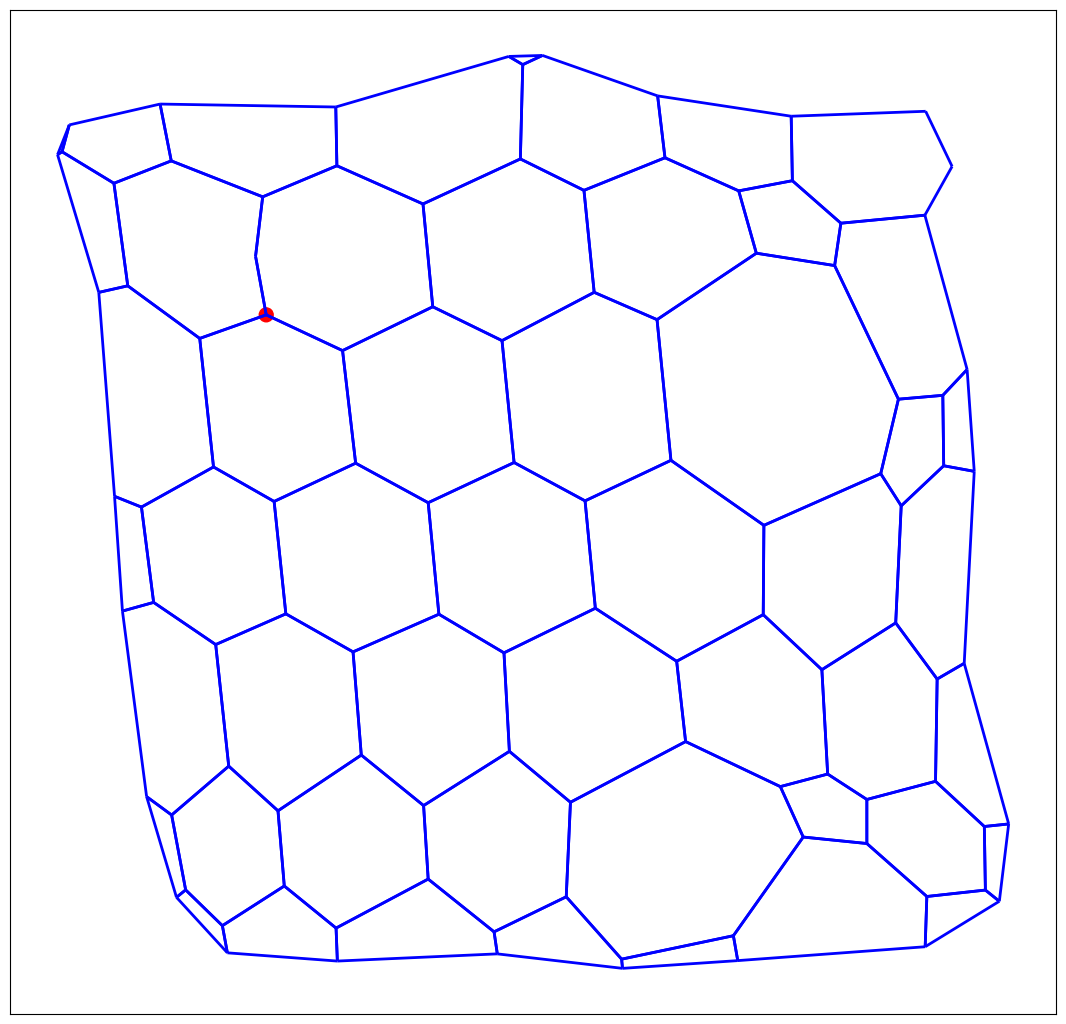

In [75]:
auxFunctions.highlight_vertices(cellmap_init, geom, [30], default_color='white', highlight_color='red', default_size=50, highlight_size=100)


In [76]:
cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index = split_vertex(cellmap_init, 30, geom, energyContributions_model, distance=0.1, retry_attempts=3)


Open faces touching new vertex: [30.0, 38.0]
Topology changed!
 Successfully divided vertex 30 → new vertex 103


(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

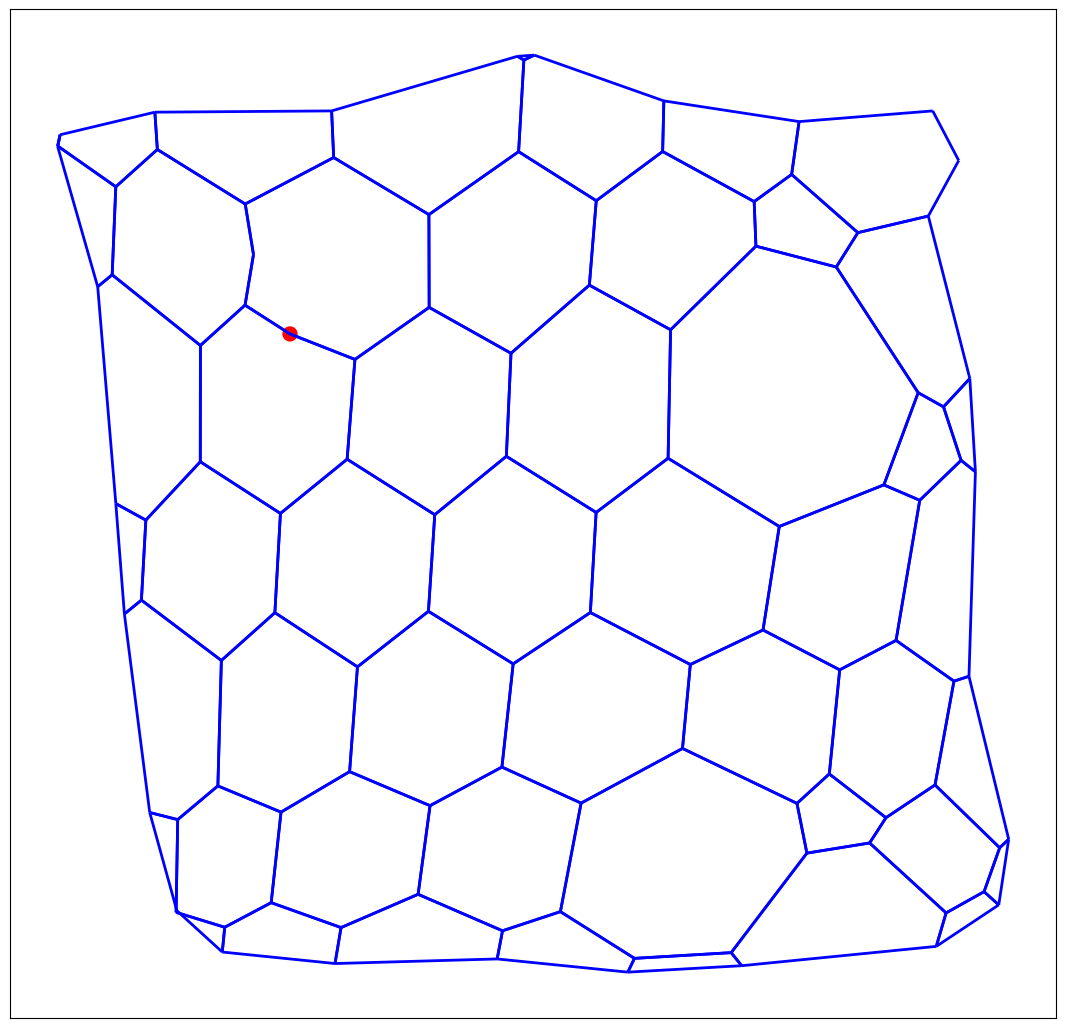

In [77]:
auxFunctions.highlight_vertices(cellmap, geom, [new_vert_index], default_color='white', highlight_color='red', default_size=50, highlight_size=100)


### Code to test division was carried out correctly

In [78]:
def debug_full_face_edges(cellmap, new_vert):
    """Show ALL edges of faces that contain the new vertex."""
    
    print("\n" + "="*50)
    print(f"NEW VERTEX: {new_vert}")
    print("="*50)
    
    # Find edges connected to new vertex
    edges_from_new = cellmap.edge_df[
        (cellmap.edge_df["srce"] == new_vert) | (cellmap.edge_df["trgt"] == new_vert)
    ]
    
    # Get unique faces from these edges
    faces = edges_from_new["face"].dropna().unique()
    
    print(f"\nFaces containing vertex {new_vert}: {sorted(faces)}")
    
    for face in sorted(faces):
        print("\n" + "-"*40)
        print(f"FACE {face} — ALL EDGES:")
        print("-"*40)
        
        # Get ALL edges belonging to this face
        all_face_edges = cellmap.edge_df[cellmap.edge_df["face"] == face]
        
        print(f"Total edges in face {face}: {len(all_face_edges)}")
        print("\nEdge list (in order around face):")
        
        for idx, row in all_face_edges.iterrows():
            marker = "← NEW VERTEX" if (row['srce'] == new_vert or row['trgt'] == new_vert) else ""
            print(f"  Edge {idx}: {row['srce']} → {row['trgt']}{marker}")
        
        # Show vertices in order around the face
        print(f"\nVertices in face {face} (in order):")
        vertices = []
        current_edge = all_face_edges.iloc[0]
        current_vert = current_edge['srce']
        
        for _ in range(len(all_face_edges)):
            vertices.append(current_vert)
            next_edge = all_face_edges[
                (all_face_edges['srce'] == current_vert)
            ]
            if not next_edge.empty:
                current_vert = next_edge.iloc[0]['trgt']
        
        vertices.append(vertices[0])  # Close the loop
        print(f"  {' → '.join(str(v) for v in vertices)}")
    
    print("\n" + "="*50)

In [79]:
debug_full_face_edges(cellmap, new_vert_index)


NEW VERTEX: 103

Faces containing vertex 103: [30, 38]

----------------------------------------
FACE 30 — ALL EDGES:
----------------------------------------
Total edges in face 30: 7

Edge list (in order around face):
  Edge 48: 29.0 → 35.0
  Edge 72: 30.0 → 29.0
  Edge 82: 44.0 → 103.0← NEW VERTEX
  Edge 114: 35.0 → 52.0
  Edge 119: 54.0 → 44.0
  Edge 120: 52.0 → 54.0
  Edge 280: 103.0 → 30.0← NEW VERTEX

Vertices in face 30 (in order):
  29.0 → 35.0 → 52.0 → 54.0 → 44.0 → 103.0 → 30.0 → 29.0

----------------------------------------
FACE 38 — ALL EDGES:
----------------------------------------
Total edges in face 38: 8

Edge list (in order around face):
  Edge 58: 37.0 → 39.0
  Edge 67: 13.0 → 37.0
  Edge 74: 39.0 → 102.0
  Edge 76: 42.0 → 13.0
  Edge 81: 103.0 → 44.0← NEW VERTEX
  Edge 84: 44.0 → 42.0
  Edge 278: 102.0 → 30.0
  Edge 279: 30.0 → 103.0← NEW VERTEX

Vertices in face 38 (in order):
  37.0 → 39.0 → 102.0 → 30.0 → 103.0 → 44.0 → 42.0 → 13.0 → 37.0



In [ ]:
def check_face_orientation(cellmap, face_id):
    """
    Check if all edges in a face form a consistent directed loop.
    
    Returns:
    - consistent: True if edges form a continuous loop
    - orientation: 'clockwise' or 'counterclockwise' (if consistent)
    """
    
    # Get all edges belonging to this face
    face_edges = cellmap.edge_df[cellmap.edge_df["face"] == face_id].copy()
    
    if len(face_edges) == 0:
        print(f"Face {face_id}: No edges found")
        return False, None
    
    print(f"\n{'='*50}")
    print(f"FACE {face_id} — DIRECTION CHECK")
    print(f"{'='*50}")
    
    # Build the edge sequence
    edges_list = face_edges.index.tolist()
    
    # Start with first edge
    current_srce = face_edges.iloc[0]['srce']
    current_trgt = face_edges.iloc[0]['trgt']
    
    sequence = [(edges_list[0], current_srce, current_trgt)]
    
    # Track used edges
    used_edges = {edges_list[0]}
    current_vert = current_trgt
    
    # Follow the loop
    consistent = True
    for _ in range(len(face_edges) - 1):
        # Find next edge where srce == current_vert
        next_edge = face_edges[face_edges['srce'] == current_vert]
        
        if next_edge.empty:
            print(f"BREAK: No edge starting at {current_vert}")
            consistent = False
            break
        
        if len(next_edge) > 1:
            print(f" WARNING: Multiple edges starting at {current_vert}: {next_edge.index.tolist()}")
        
        next_id = next_edge.index[0]
        next_srce = next_edge.iloc[0]['srce']
        next_trgt = next_edge.iloc[0]['trgt']
        
        if next_id in used_edges:
            print(f"BREAK: Edge {next_id} already used (cycle detected early)")
            consistent = False
            break
        
        sequence.append((next_id, next_srce, next_trgt))
        used_edges.add(next_id)
        current_vert = next_trgt
    
    # Check if we returned to start
    if consistent and current_vert != sequence[0][1]:
        print(f"BREAK: Loop not closed — ended at {current_vert}, started at {sequence[0][1]}")
        consistent = False
    
    # Print the sequence
    print(f"\nEdge sequence:")
    for i, (eid, s, t) in enumerate(sequence):
        arrow = "→" if i < len(sequence)-1 else "→ (back to start)"
        print(f"  Edge {eid}: {s} {arrow} {t}")
    
    if consistent:
        print(f"\n FACE {face_id} is CONSISTENT — forms a closed loop")
        
        # Determine orientation (clockwise or counterclockwise)
        # Calculate signed area (shoelace formula)
        vertices = []
        for _, s, t in sequence:
            vertices.append(s)
        vertices.append(sequence[0][1])  # Add closing vertex
        
        # Get coordinates
        coords = []
        for v in vertices:
            x = cellmap.vert_df.loc[v, 'x']
            y = cellmap.vert_df.loc[v, 'y']
            coords.append((x, y))
        
        # Shoelace formula
        area = 0
        for i in range(len(coords) - 1):
            area += coords[i][0] * coords[i+1][1] - coords[i+1][0] * coords[i][1]
        area /= 2
        
        orientation = "counterclockwise" if area > 0 else "clockwise"
        print(f"  Orientation: {orientation} (area = {area:.4f})")
        
        return True, orientation
    
    else:
        print(f"\nFACE {face_id} is INCONSISTENT")
        return False, None


def check_both_faces(cellmap, new_vert):
    """Check orientation for both faces containing new vertex."""
    
    print("\n" + "="*60)
    print("CHECKING FACE ORIENTATIONS FOR NEW VERTEX", new_vert)
    print("="*60)
    
    # Find faces containing new_vert
    edges = cellmap.edge_df[
        (cellmap.edge_df["srce"] == new_vert) | (cellmap.edge_df["trgt"] == new_vert)
    ]
    faces = edges["face"].dropna().unique()
    
    results = {}
    for face_id in sorted(faces):
        consistent, orientation = check_face_orientation(cellmap, face_id)
        results[face_id] = (consistent, orientation)
    
    print("\n" + "="*60)
    print("SUMMARY:")
    print("="*60)
    for face_id, (consistent, orientation) in results.items():
        status = "correct" if consistent else "wrong"
        print(f"  {status} Face {face_id}: {orientation if consistent else 'INCONSISTENT'}")
    
    return results

In [81]:
check_both_faces(cellmap, chosen_vertex)



CHECKING FACE ORIENTATIONS FOR NEW VERTEX 30

FACE 30 — DIRECTION CHECK

Edge sequence:
  Edge 48: 29.0 → 35.0
  Edge 114: 35.0 → 52.0
  Edge 120: 52.0 → 54.0
  Edge 119: 54.0 → 44.0
  Edge 82: 44.0 → 103.0
  Edge 280: 103.0 → 30.0
  Edge 72: 30.0 → (back to start) 29.0

 FACE 30 is CONSISTENT — forms a closed loop
  Orientation: counterclockwise (area = 0.9647)

FACE 37 — DIRECTION CHECK

Edge sequence:
  Edge 10: 9.0 → 8.0
  Edge 46: 8.0 → 29.0
  Edge 71: 29.0 → 30.0
  Edge 277: 30.0 → 102.0
  Edge 73: 102.0 → 39.0
  Edge 61: 39.0 → 38.0
  Edge 70: 38.0 → (back to start) 9.0

 FACE 37 is CONSISTENT — forms a closed loop
  Orientation: counterclockwise (area = 0.7878)

FACE 38 — DIRECTION CHECK

Edge sequence:
  Edge 58: 37.0 → 39.0
  Edge 74: 39.0 → 102.0
  Edge 278: 102.0 → 30.0
  Edge 279: 30.0 → 103.0
  Edge 81: 103.0 → 44.0
  Edge 84: 44.0 → 42.0
  Edge 76: 42.0 → 13.0
  Edge 67: 13.0 → (back to start) 37.0

 FACE 38 is CONSISTENT — forms a closed loop
  Orientation: countercloc

{30: (True, 'counterclockwise'),
 37: (True, 'counterclockwise'),
 38: (True, 'counterclockwise')}